# MobileNetV3-Large Transfer Learning for Waste Classification

## Smart Waste Classification System Using Deep Learning

This notebook implements, fine-tunes, and evaluates MobileNetV3-Large for
classifying TrashNet images into six waste categories:

- Cardboard
- Glass
- Metal
- Paper
- Plastic
- Trash

MobileNetV3-Large is the final mandatory architecture in the project's
five-model comparison:

1. Baseline CNN
2. ResNet50
3. EfficientNet-B0
4. DenseNet121
5. MobileNetV3-Large

The experiment reuses the same:

- Train, validation, and test split manifest
- Image size
- ImageNet normalization
- Training augmentation
- Class weighting
- Evaluation metrics
- Error-analysis procedure
- Latency-measurement procedure

This ensures that performance differences are caused primarily by model
architecture rather than inconsistent experimental conditions.

##  Experiment Objectives

The objectives of this notebook are to:

1. Load MobileNetV3-Large using ImageNet-pretrained weights.
2. Replace its original 1,000-class ImageNet output layer with a six-class
   TrashNet output layer.
3. Train the classifier while keeping the feature extractor frozen.
4. Fine-tune selected upper MobileNetV3 feature blocks using a lower learning
   rate.
5. Preserve the same dataset partitions and preprocessing used by the previous
   models.
6. Handle class imbalance using class weights derived only from the training
   split.
7. Evaluate the final model using:

   - Accuracy
   - Precision
   - Recall
   - F1-score
   - ROC-AUC
   - Confusion matrix
   - Per-class accuracy
   - Learning curves

8. Analyze class confusion and high-confidence errors.
9. Measure model size and single-image CPU inference latency.
10. Save a deployment-ready model package and standardized comparison results.

##  MobileNetV3-Large Architecture Overview

MobileNetV3 is a convolutional neural-network family designed for efficient
image classification on devices with limited computational resources.

MobileNetV3-Large combines several efficiency-focused design ideas.

### Depthwise separable convolution

A standard convolution performs spatial filtering and channel mixing together.

A depthwise separable convolution separates these operations:

1. A depthwise convolution applies one spatial filter to each input channel.
2. A pointwise `1 × 1` convolution combines information across channels.

This substantially reduces computation compared with a conventional
convolution.

### Inverted residual blocks

An inverted residual block:

1. Expands a compact input representation.
2. Applies a depthwise convolution.
3. Projects the representation back to a smaller number of channels.

A residual connection is used when the input and output dimensions are
compatible.

### Squeeze-and-excitation attention

Selected MobileNetV3 blocks use squeeze-and-excitation modules.

These modules learn which feature channels are most useful and assign larger
weights to informative channels.

### Hardswish activation

MobileNetV3 uses the Hardswish activation function in selected layers.

Hardswish approximates the Swish activation while remaining more efficient for
deployment.

### Why MobileNetV3-Large is included

MobileNetV3-Large is expected to provide a useful balance between:

- Predictive accuracy
- Model size
- Parameter count
- CPU inference speed
- Deployment practicality

This makes it an important candidate for the final production model.

In [14]:
import json
import os
import platform
import random
import sys
import time

from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
import torchvision

from PIL import Image, UnidentifiedImageError

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)

from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import (
    MobileNet_V3_Large_Weights,
    mobilenet_v3_large,
)

In [15]:
print("=" * 72)
print("MOBILENETV3-LARGE EXPERIMENT ENVIRONMENT")
print("=" * 72)

print(f"Python executable : {sys.executable}")
print(f"Python version    : {platform.python_version()}")
print(f"PyTorch version   : {torch.__version__}")
print(f"TorchVision       : {torchvision.__version__}")
print(f"Operating system  : {platform.platform()}")

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("-" * 72)
print(f"CUDA available    : {torch.cuda.is_available()}")
print(f"Selected device   : {DEVICE}")

if DEVICE.type == "cuda":
    print(f"GPU name          : {torch.cuda.get_device_name(0)}")
else:
    print("Hardware note     : CPU-only PyTorch environment")

print("=" * 72)

MOBILENETV3-LARGE EXPERIMENT ENVIRONMENT
Python executable : c:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\.venv\Scripts\python.exe
Python version    : 3.12.10
PyTorch version   : 2.13.0+cpu
TorchVision       : 0.28.0+cpu
Operating system  : Windows-11-10.0.26200-SP0
------------------------------------------------------------------------
CUDA available    : False
Selected device   : cpu
Hardware note     : CPU-only PyTorch environment


In [16]:
SEED = 42


def set_random_seed(seed: int) -> None:
    """
    Configure random generators used by Python, NumPy, and PyTorch.
    """
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_random_seed(SEED)

print(f"Random seed configured: {SEED}")

Random seed configured: 42


In [17]:
EXPERIMENT_NAME = "mobilenet_v3_large"
MODEL_VERSION = "1.0.0"

IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
IMAGE_SIZE = (IMAGE_HEIGHT, IMAGE_WIDTH)

BATCH_SIZE = 16
NUM_WORKERS = 0

HEAD_EPOCHS = 10
FINE_TUNE_EPOCHS = 5

HEAD_LEARNING_RATE = 1e-3
BACKBONE_FINE_TUNE_LEARNING_RATE = 1e-5
CLASSIFIER_FINE_TUNE_LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4
DROPOUT_RATE = 0.30

EARLY_STOPPING_PATIENCE = 5
MINIMUM_IMPROVEMENT = 1e-4

FINE_TUNE_LAST_N_BLOCKS = 3

PROJECT_ROOT = Path("..")

DATA_DIRECTORY = PROJECT_ROOT / "data"
SPLITS_DIRECTORY = DATA_DIRECTORY / "splits"

MODEL_DIRECTORY = PROJECT_ROOT / "models"
RESULTS_DIRECTORY = PROJECT_ROOT / "results"
FIGURES_DIRECTORY = RESULTS_DIRECTORY / "figures"
LOGS_DIRECTORY = PROJECT_ROOT / "logs"

MODEL_DIRECTORY.mkdir(parents=True, exist_ok=True)
RESULTS_DIRECTORY.mkdir(parents=True, exist_ok=True)
FIGURES_DIRECTORY.mkdir(parents=True, exist_ok=True)
LOGS_DIRECTORY.mkdir(parents=True, exist_ok=True)

SPLIT_MANIFEST_PATH = (
    SPLITS_DIRECTORY / "split_manifest.csv"
)

FROZEN_CHECKPOINT_PATH = (
    MODEL_DIRECTORY
    / "mobilenet_v3_large_frozen_best.pt"
)

FINE_TUNED_CHECKPOINT_PATH = (
    MODEL_DIRECTORY
    / "mobilenet_v3_large_finetuned_best.pt"
)

DEPLOYMENT_MODEL_PATH = (
    MODEL_DIRECTORY
    / "mobilenet_v3_large_deployment.pt"
)

print(f"Experiment name          : {EXPERIMENT_NAME}")
print(f"Model version            : {MODEL_VERSION}")
print(f"Image size               : {IMAGE_SIZE}")
print(f"Batch size               : {BATCH_SIZE}")
print(f"Device                   : {DEVICE}")
print(f"Fine-tuned feature blocks: {FINE_TUNE_LAST_N_BLOCKS}")
print(f"Manifest path            : {SPLIT_MANIFEST_PATH.resolve()}")

Experiment name          : mobilenet_v3_large
Model version            : 1.0.0
Image size               : (224, 224)
Batch size               : 16
Device                   : cpu
Fine-tuned feature blocks: 3
Manifest path            : C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\splits\split_manifest.csv


In [18]:
if BATCH_SIZE <= 0:
    raise ValueError(
        "BATCH_SIZE must be greater than zero."
    )

if HEAD_EPOCHS <= 0:
    raise ValueError(
        "HEAD_EPOCHS must be greater than zero."
    )

if FINE_TUNE_EPOCHS <= 0:
    raise ValueError(
        "FINE_TUNE_EPOCHS must be greater than zero."
    )

if not 0.0 <= DROPOUT_RATE < 1.0:
    raise ValueError(
        "DROPOUT_RATE must be between 0 and 1."
    )

if FINE_TUNE_LAST_N_BLOCKS <= 0:
    raise ValueError(
        "FINE_TUNE_LAST_N_BLOCKS must be greater than zero."
    )

print(
    "MobileNetV3-Large experiment "
    "configuration validated successfully."
)

MobileNetV3-Large experiment configuration validated successfully.


In [20]:
if not SPLIT_MANIFEST_PATH.exists():
    raise FileNotFoundError(
        "The dataset split manifest was not found at:\n"
        f"{SPLIT_MANIFEST_PATH.resolve()}"
    )

split_manifest = pd.read_csv(
    SPLIT_MANIFEST_PATH
)

print(
    f"Split manifest loaded successfully: "
    f"{len(split_manifest):,} records"
)

split_manifest.head()

Split manifest loaded successfully: 2,521 records


,class_name,split,source_path,destination_path,sha256
0,cardboard,train,data\raw\trashnet\cardboard\cardboard235.jpg,data\processed\train\cardboard\cardboard235.jpg,d550d9d6c2b831d3dee5bb985a259a4f872df22baaf2a1...
1,cardboard,train,data\raw\trashnet\cardboard\cardboard213.jpg,data\processed\train\cardboard\cardboard213.jpg,b3c979a3f4b7246548b51ee34782dfab7e146a569511f6...
2,cardboard,train,data\raw\trashnet\cardboard\cardboard169.jpg,data\processed\train\cardboard\cardboard169.jpg,a6b0a3670259dd8027b06e87ae292e8eca1c87634d785e...
3,cardboard,train,data\raw\trashnet\cardboard\cardboard138.jpg,data\processed\train\cardboard\cardboard138.jpg,7d70edc60cfb2c34a6c9d636200d39f61b0c5d7ed4a69b...
4,cardboard,train,data\raw\trashnet\cardboard\cardboard334.jpg,data\processed\train\cardboard\cardboard334.jpg,e20217c46a83b281bcda09e3d2679e22292d3e3c25bc93...


In [21]:
PATH_COLUMN = "destination_path"
CLASS_COLUMN = "class_name"
SPLIT_COLUMN = "split"
HASH_COLUMN = "sha256"

required_manifest_columns = {
    PATH_COLUMN,
    CLASS_COLUMN,
    SPLIT_COLUMN,
    HASH_COLUMN,
}

missing_manifest_columns = (
    required_manifest_columns
    - set(split_manifest.columns)
)

if missing_manifest_columns:
    raise KeyError(
        "The manifest is missing required columns: "
        + ", ".join(
            sorted(missing_manifest_columns)
        )
    )

print("Required manifest columns verified:")
print(sorted(required_manifest_columns))

Required manifest columns verified:
['class_name', 'destination_path', 'sha256', 'split']


In [22]:
def resolve_image_path(
    stored_path: str,
    project_root: Path,
) -> Path:
    """
    Convert a manifest path into an absolute path.

    Parameters
    ----------
    stored_path:
        Path stored in the split manifest.

    project_root:
        Root directory of the project.

    Returns
    -------
    Path
        Resolved absolute image path.
    """
    image_path = Path(stored_path)

    if image_path.is_absolute():
        return image_path

    return (
        project_root / image_path
    ).resolve()


split_manifest = split_manifest.copy()

split_manifest["resolved_path"] = (
    split_manifest[PATH_COLUMN]
    .apply(
        lambda stored_path: resolve_image_path(
            stored_path=stored_path,
            project_root=PROJECT_ROOT,
        )
    )
)

split_manifest["file_exists"] = (
    split_manifest["resolved_path"]
    .apply(Path.exists)
)

missing_image_records = split_manifest[
    split_manifest["file_exists"] == False
].copy()

if not missing_image_records.empty:
    display(
        missing_image_records[
            [
                CLASS_COLUMN,
                SPLIT_COLUMN,
                PATH_COLUMN,
                "resolved_path",
            ]
        ].head(20)
    )

    raise FileNotFoundError(
        f"{len(missing_image_records)} manifest images "
        "could not be found."
    )

print(
    f"All {len(split_manifest):,} manifest image paths "
    "were resolved successfully."
)

All 2,521 manifest image paths were resolved successfully.


In [23]:
EXPECTED_SPLITS = {
    "train",
    "validation",
    "test",
}

actual_splits = set(
    split_manifest[SPLIT_COLUMN]
    .astype(str)
    .str.lower()
    .unique()
)

unexpected_splits = (
    actual_splits - EXPECTED_SPLITS
)

missing_splits = (
    EXPECTED_SPLITS - actual_splits
)

if unexpected_splits:
    raise ValueError(
        "Unexpected dataset split labels: "
        + ", ".join(
            sorted(unexpected_splits)
        )
    )

if missing_splits:
    raise ValueError(
        "Required dataset splits are missing: "
        + ", ".join(
            sorted(missing_splits)
        )
    )

print("Dataset split labels verified:")
print(sorted(actual_splits))

Dataset split labels verified:
['test', 'train', 'validation']


In [24]:
hash_split_counts = (
    split_manifest
    .groupby(HASH_COLUMN)[SPLIT_COLUMN]
    .nunique()
)

cross_split_hashes = hash_split_counts[
    hash_split_counts > 1
]

if len(cross_split_hashes) > 0:
    leaked_records = split_manifest[
        split_manifest[HASH_COLUMN].isin(
            cross_split_hashes.index
        )
    ].sort_values(
        [
            HASH_COLUMN,
            SPLIT_COLUMN,
        ]
    )

    display(
        leaked_records[
            [
                HASH_COLUMN,
                CLASS_COLUMN,
                SPLIT_COLUMN,
                PATH_COLUMN,
            ]
        ].head(30)
    )

    raise ValueError(
        "Data leakage detected: identical image content "
        "appears in multiple dataset splits."
    )

print(
    "No duplicate image content was found "
    "across different dataset splits."
)

No duplicate image content was found across different dataset splits.


In [25]:
hash_class_counts = (
    split_manifest
    .groupby(HASH_COLUMN)[CLASS_COLUMN]
    .nunique()
)

conflicting_label_hashes = hash_class_counts[
    hash_class_counts > 1
]

if len(conflicting_label_hashes) > 0:
    conflicting_records = split_manifest[
        split_manifest[HASH_COLUMN].isin(
            conflicting_label_hashes.index
        )
    ].sort_values(
        [
            HASH_COLUMN,
            CLASS_COLUMN,
        ]
    )

    display(
        conflicting_records[
            [
                HASH_COLUMN,
                CLASS_COLUMN,
                SPLIT_COLUMN,
                PATH_COLUMN,
            ]
        ].head(30)
    )

    raise ValueError(
        "Conflicting class labels were found "
        "for identical image content."
    )

print(
    "No conflicting class assignments "
    "were detected."
)

No conflicting class assignments were detected.


In [26]:
class_names = sorted(
    split_manifest[CLASS_COLUMN]
    .unique()
    .tolist()
)

class_to_index = {
    class_name: class_index
    for class_index, class_name
    in enumerate(class_names)
}

index_to_class = {
    class_index: class_name
    for class_name, class_index
    in class_to_index.items()
}

NUM_CLASSES = len(class_names)

split_manifest["class_index"] = (
    split_manifest[CLASS_COLUMN]
    .map(class_to_index)
)

if split_manifest[
    "class_index"
].isna().any():
    raise ValueError(
        "One or more class names could not "
        "be converted into class indices."
    )

split_manifest["class_index"] = (
    split_manifest["class_index"]
    .astype(int)
)

print(f"Number of classes: {NUM_CLASSES}")

for class_name, class_index in (
    class_to_index.items()
):
    print(
        f"{class_index}: {class_name}"
    )

Number of classes: 6
0: cardboard
1: glass
2: metal
3: paper
4: plastic
5: trash


In [27]:
train_manifest = (
    split_manifest[
        split_manifest[SPLIT_COLUMN]
        == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

validation_manifest = (
    split_manifest[
        split_manifest[SPLIT_COLUMN]
        == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

test_manifest = (
    split_manifest[
        split_manifest[SPLIT_COLUMN]
        == "test"
    ]
    .copy()
    .reset_index(drop=True)
)

print(f"Training images   : {len(train_manifest):,}")
print(f"Validation images : {len(validation_manifest):,}")
print(f"Test images       : {len(test_manifest):,}")

combined_record_count = (
    len(train_manifest)
    + len(validation_manifest)
    + len(test_manifest)
)

if combined_record_count != len(
    split_manifest
):
    raise ValueError(
        "The separated dataset sizes do not "
        "match the complete manifest."
    )

Training images   : 1,762
Validation images : 378
Test images       : 381


In [28]:
split_class_distribution = pd.crosstab(
    split_manifest[CLASS_COLUMN],
    split_manifest[SPLIT_COLUMN],
)

split_class_distribution = (
    split_class_distribution.reindex(
        index=class_names,
        columns=[
            "train",
            "validation",
            "test",
        ],
        fill_value=0,
    )
)

split_class_distribution[
    "total"
] = split_class_distribution.sum(axis=1)

split_class_distribution

split,train,validation,test,total
class_name,,,,
cardboard,282,60,61,403
glass,348,75,75,498
metal,286,61,62,409
paper,415,89,90,594
plastic,336,72,72,480
trash,95,21,21,137


In [29]:
IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406,
]

IMAGENET_STANDARD_DEVIATION = [
    0.229,
    0.224,
    0.225,
]

training_transform = transforms.Compose(
    [
        transforms.RandomResizedCrop(
            size=IMAGE_SIZE,
            scale=(0.80, 1.00),
            ratio=(0.90, 1.10),
        ),
        transforms.RandomHorizontalFlip(
            p=0.50,
        ),
        transforms.RandomRotation(
            degrees=10,
        ),
        transforms.ColorJitter(
            brightness=0.15,
            contrast=0.15,
            saturation=0.10,
            hue=0.02,
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STANDARD_DEVIATION,
        ),
    ]
)

evaluation_transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(
            IMAGE_SIZE
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STANDARD_DEVIATION,
        ),
    ]
)

print(
    "Training and evaluation transforms "
    "configured successfully."
)

Training and evaluation transforms configured successfully.


In [30]:
class WasteClassificationDataset(
    Dataset
):
    """
    Manifest-based TrashNet classification dataset.
    """

    def __init__(
        self,
        manifest: pd.DataFrame,
        transform=None,
    ) -> None:
        self.manifest = (
            manifest.copy()
            .reset_index(drop=True)
        )

        self.transform = transform

        required_columns = {
            "resolved_path",
            "class_index",
        }

        missing_columns = (
            required_columns
            - set(self.manifest.columns)
        )

        if missing_columns:
            raise ValueError(
                "Dataset manifest is missing columns: "
                + ", ".join(
                    sorted(missing_columns)
                )
            )

    def __len__(self) -> int:
        return len(self.manifest)

    def __getitem__(
        self,
        index: int,
    ) -> dict:
        record = self.manifest.iloc[
            index
        ]

        image_path = Path(
            record["resolved_path"]
        )

        class_index = int(
            record["class_index"]
        )

        try:
            with Image.open(
                image_path
            ) as image:
                image = image.convert(
                    "RGB"
                )

        except (
            FileNotFoundError,
            UnidentifiedImageError,
            OSError,
        ) as error:
            raise RuntimeError(
                f"Unable to load image: "
                f"{image_path}"
            ) from error

        if self.transform is not None:
            image = self.transform(image)

        return {
            "image": image,
            "label": class_index,
            "path": str(image_path),
        }

In [31]:
train_dataset = (
    WasteClassificationDataset(
        manifest=train_manifest,
        transform=training_transform,
    )
)

validation_dataset = (
    WasteClassificationDataset(
        manifest=validation_manifest,
        transform=evaluation_transform,
    )
)

test_dataset = (
    WasteClassificationDataset(
        manifest=test_manifest,
        transform=evaluation_transform,
    )
)

print(f"Training dataset   : {len(train_dataset):,}")
print(f"Validation dataset : {len(validation_dataset):,}")
print(f"Test dataset       : {len(test_dataset):,}")

Training dataset   : 1,762
Validation dataset : 378
Test dataset       : 381


In [32]:
data_loader_generator = (
    torch.Generator()
)

data_loader_generator.manual_seed(
    SEED
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(
        DEVICE.type == "cuda"
    ),
    generator=data_loader_generator,
)

validation_loader = DataLoader(
    dataset=validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(
        DEVICE.type == "cuda"
    ),
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(
        DEVICE.type == "cuda"
    ),
)

print(f"Training batches   : {len(train_loader)}")
print(f"Validation batches : {len(validation_loader)}")
print(f"Test batches       : {len(test_loader)}")

Training batches   : 111
Validation batches : 24
Test batches       : 24


In [33]:
sample_batch = next(
    iter(train_loader)
)

sample_images = sample_batch[
    "image"
]

sample_labels = sample_batch[
    "label"
]

sample_paths = sample_batch[
    "path"
]

print(
    f"Image batch shape : "
    f"{sample_images.shape}"
)

print(
    f"Label batch shape : "
    f"{sample_labels.shape}"
)

print(
    f"Image dtype       : "
    f"{sample_images.dtype}"
)

print(
    f"Label dtype       : "
    f"{sample_labels.dtype}"
)

print(
    f"First class       : "
    f"{index_to_class[int(sample_labels[0])]}"
)

print(
    f"First path        : "
    f"{sample_paths[0]}"
)

expected_batch_shape = (
    sample_images.shape[0],
    3,
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
)

if tuple(
    sample_images.shape
) != expected_batch_shape:
    raise ValueError(
        "Unexpected training batch shape."
    )

Image batch shape : torch.Size([16, 3, 224, 224])
Label batch shape : torch.Size([16])
Image dtype       : torch.float32
Label dtype       : torch.int64
First class       : plastic
First path        : C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\train\plastic\plastic379.jpg


In [34]:
training_class_counts = (
    train_manifest[CLASS_COLUMN]
    .value_counts()
    .reindex(class_names)
)

if training_class_counts.isna().any():
    raise ValueError(
        "At least one class is absent "
        "from the training split."
    )

total_training_samples = len(
    train_manifest
)

class_weights_array = (
    total_training_samples
    / (
        NUM_CLASSES
        * training_class_counts.values
    )
)

class_weights = torch.tensor(
    class_weights_array,
    dtype=torch.float32,
    device=DEVICE,
)

class_weight_table = pd.DataFrame(
    {
        "class_name": class_names,
        "training_samples": (
            training_class_counts.values
        ),
        "class_weight": (
            class_weights_array
        ),
    }
)

class_weight_table

,class_name,training_samples,class_weight
0,cardboard,282,1.041371
1,glass,348,0.843870
2,metal,286,1.026807
3,paper,415,0.707631
4,plastic,336,0.874008
5,trash,95,3.091228


In [35]:
MOBILENET_WEIGHTS = (
    MobileNet_V3_Large_Weights.DEFAULT
)

mobilenet_model = (
    mobilenet_v3_large(
        weights=MOBILENET_WEIGHTS
    )
)

print(
    "MobileNetV3-Large loaded successfully."
)

print("\nOriginal classifier:")

print(
    mobilenet_model.classifier
)

MobileNetV3-Large loaded successfully.

Original classifier:
Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=1000, bias=True)
)


In [37]:
for parameter in (
    mobilenet_model.features.parameters()
):
    parameter.requires_grad = False

classifier_input_features = (
    mobilenet_model.classifier[3]
    .in_features
)

mobilenet_model.classifier[2] = (
    nn.Dropout(
        p=DROPOUT_RATE,
        inplace=True,
    )
)

mobilenet_model.classifier[3] = (
    nn.Linear(
        in_features=(
            classifier_input_features
        ),
        out_features=NUM_CLASSES,
    )
)

mobilenet_model = (
    mobilenet_model.to(DEVICE)
)

print(
    "Updated MobileNetV3-Large classifier:"
)

print(
    mobilenet_model.classifier
)

Updated MobileNetV3-Large classifier:
Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.3, inplace=True)
  (3): Linear(in_features=1280, out_features=6, bias=True)
)


In [38]:
def count_model_parameters(
    model: nn.Module,
) -> dict:
    """
    Count total, trainable, and frozen model parameters.
    """
    total_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    frozen_parameters = (
        total_parameters
        - trainable_parameters
    )

    return {
        "total_parameters": int(
            total_parameters
        ),
        "trainable_parameters": int(
            trainable_parameters
        ),
        "frozen_parameters": int(
            frozen_parameters
        ),
    }


frozen_parameter_summary = (
    count_model_parameters(
        mobilenet_model
    )
)

for key, value in (
    frozen_parameter_summary.items()
):
    print(
        f"{key}: {value:,}"
    )

total_parameters: 4,209,718
trainable_parameters: 1,237,766
frozen_parameters: 2,971,952


In [39]:
mobilenet_model.eval()

smoke_test_batch = next(
    iter(train_loader)
)

smoke_test_images = (
    smoke_test_batch["image"]
    .to(DEVICE)
)

smoke_test_labels = (
    smoke_test_batch["label"]
    .to(DEVICE)
)

with torch.inference_mode():
    smoke_test_logits = (
        mobilenet_model(
            smoke_test_images
        )
    )

print(
    "Input shape :",
    smoke_test_images.shape,
)

print(
    "Label shape :",
    smoke_test_labels.shape,
)

print(
    "Output shape:",
    smoke_test_logits.shape,
)

expected_output_shape = (
    smoke_test_images.shape[0],
    NUM_CLASSES,
)

if tuple(
    smoke_test_logits.shape
) != expected_output_shape:
    raise ValueError(
        "Unexpected MobileNetV3 output shape. "
        f"Expected {expected_output_shape}, "
        f"received {tuple(smoke_test_logits.shape)}."
    )

if not torch.isfinite(
    smoke_test_logits
).all():
    raise ValueError(
        "The MobileNetV3 smoke-test output "
        "contains invalid values."
    )

print(
    "Forward-pass smoke test passed."
)

Input shape : torch.Size([16, 3, 224, 224])
Label shape : torch.Size([16])
Output shape: torch.Size([16, 6])
Forward-pass smoke test passed.


In [40]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

trainable_parameters = [
    parameter
    for parameter in mobilenet_model.parameters()
    if parameter.requires_grad
]

optimizer = Adam(
    params=trainable_parameters,
    lr=HEAD_LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = ReduceLROnPlateau(
    optimizer=optimizer,
    mode="min",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
)

smoke_test_loss = criterion(
    smoke_test_logits,
    smoke_test_labels,
)

if not torch.isfinite(
    smoke_test_loss
):
    raise ValueError(
        "Smoke-test loss is invalid."
    )

print(
    f"Smoke-test weighted loss: "
    f"{smoke_test_loss.item():.4f}"
)

print(
    "Frozen-stage optimizer and scheduler "
    "configured successfully."
)

Smoke-test weighted loss: 1.7898
Frozen-stage optimizer and scheduler configured successfully.


In [41]:
def calculate_correct_predictions(
    logits: torch.Tensor,
    labels: torch.Tensor,
) -> int:
    """
    Count correct predictions in one batch.
    """
    predictions = torch.argmax(
        logits,
        dim=1,
    )

    return int(
        (
            predictions == labels
        )
        .sum()
        .item()
    )

In [42]:
def calculate_correct_predictions(
    logits: torch.Tensor,
    labels: torch.Tensor,
) -> int:
    """
    Count correct predictions in one batch.
    """
    predictions = torch.argmax(
        logits,
        dim=1,
    )

    return int(
        (
            predictions == labels
        )
        .sum()
        .item()
    )

In [44]:
def train_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    loss_function: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    keep_batch_norm_frozen: bool = False,
) -> dict:
    """
    Train a model for one complete epoch.
    """
    model.train()

    if keep_batch_norm_frozen:
        set_batch_normalization_to_evaluation(
            model
        )

    running_loss = 0.0
    correct_predictions = 0
    processed_samples = 0

    for batch in data_loader:
        images = batch["image"].to(
            device,
            non_blocking=True,
        )

        labels = batch["label"].to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(images)

        loss = loss_function(
            logits,
            labels,
        )

        if not torch.isfinite(loss):
            raise RuntimeError(
                "A non-finite training loss "
                "was encountered."
            )

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        correct_predictions += (
            calculate_correct_predictions(
                logits,
                labels,
            )
        )

        processed_samples += batch_size

    if processed_samples == 0:
        raise RuntimeError(
            "The training DataLoader "
            "returned no samples."
        )

    return {
        "loss": float(
            running_loss
            / processed_samples
        ),
        "accuracy": float(
            correct_predictions
            / processed_samples
        ),
        "correct_predictions": int(
            correct_predictions
        ),
        "sample_count": int(
            processed_samples
        ),
    }

In [45]:
def validate_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    loss_function: nn.Module,
    device: torch.device,
) -> dict:
    """
    Evaluate a model for one complete epoch.
    """
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    processed_samples = 0

    with torch.inference_mode():
        for batch in data_loader:
            images = batch["image"].to(
                device,
                non_blocking=True,
            )

            labels = batch["label"].to(
                device,
                non_blocking=True,
            )

            logits = model(images)

            loss = loss_function(
                logits,
                labels,
            )

            if not torch.isfinite(loss):
                raise RuntimeError(
                    "A non-finite validation loss "
                    "was encountered."
                )

            batch_size = labels.size(0)

            running_loss += (
                loss.item() * batch_size
            )

            correct_predictions += (
                calculate_correct_predictions(
                    logits,
                    labels,
                )
            )

            processed_samples += batch_size

    if processed_samples == 0:
        raise RuntimeError(
            "The validation DataLoader "
            "returned no samples."
        )

    return {
        "loss": float(
            running_loss
            / processed_samples
        ),
        "accuracy": float(
            correct_predictions
            / processed_samples
        ),
        "correct_predictions": int(
            correct_predictions
        ),
        "sample_count": int(
            processed_samples
        ),
    }

In [46]:
def save_mobilenet_checkpoint(
    checkpoint_path: Path,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    validation_loss: float,
    validation_accuracy: float,
    training_stage: str,
) -> None:
    """
    Save MobileNetV3-Large weights and metadata.
    """
    checkpoint_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    checkpoint = {
        "architecture": (
            "mobilenet_v3_large"
        ),
        "model_variant": "large",
        "model_version": MODEL_VERSION,
        "training_stage": (
            training_stage
        ),
        "epoch": int(epoch),
        "model_state_dict": (
            model.state_dict()
        ),
        "optimizer_state_dict": (
            optimizer.state_dict()
        ),
        "validation_loss": float(
            validation_loss
        ),
        "validation_accuracy": float(
            validation_accuracy
        ),
        "number_of_classes": (
            NUM_CLASSES
        ),
        "class_names": list(
            class_names
        ),
        "class_to_index": dict(
            class_to_index
        ),
        "image_size": list(
            IMAGE_SIZE
        ),
        "dropout_rate": float(
            DROPOUT_RATE
        ),
        "saved_at": (
            datetime.now().isoformat()
        ),
        "pytorch_version": (
            torch.__version__
        ),
        "torchvision_version": (
            torchvision.__version__
        ),
    }

    torch.save(
        checkpoint,
        checkpoint_path,
    )

In [47]:
def run_training_stage(
    model: nn.Module,
    train_loader: DataLoader,
    validation_loader: DataLoader,
    loss_function: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler,
    device: torch.device,
    maximum_epochs: int,
    checkpoint_path: Path,
    training_stage: str,
    early_stopping_patience: int,
    minimum_improvement: float,
    keep_batch_norm_frozen: bool = False,
) -> pd.DataFrame:
    """
    Run one complete training stage.
    """
    history_records = []

    best_validation_loss = float(
        "inf"
    )

    non_improving_epochs = 0

    stage_start_time = (
        time.perf_counter()
    )

    for epoch_index in range(
        maximum_epochs
    ):
        epoch_number = (
            epoch_index + 1
        )

        epoch_start_time = (
            time.perf_counter()
        )

        learning_rates = [
            group["lr"]
            for group
            in optimizer.param_groups
        ]

        training_metrics = (
            train_one_epoch(
                model=model,
                data_loader=train_loader,
                loss_function=(
                    loss_function
                ),
                optimizer=optimizer,
                device=device,
                keep_batch_norm_frozen=(
                    keep_batch_norm_frozen
                ),
            )
        )

        validation_metrics = (
            validate_one_epoch(
                model=model,
                data_loader=(
                    validation_loader
                ),
                loss_function=(
                    loss_function
                ),
                device=device,
            )
        )

        scheduler.step(
            validation_metrics[
                "loss"
            ]
        )

        validation_improved = (
            validation_metrics["loss"]
            < (
                best_validation_loss
                - minimum_improvement
            )
        )

        if validation_improved:
            best_validation_loss = (
                validation_metrics[
                    "loss"
                ]
            )

            non_improving_epochs = 0

            save_mobilenet_checkpoint(
                checkpoint_path=(
                    checkpoint_path
                ),
                model=model,
                optimizer=optimizer,
                epoch=epoch_number,
                validation_loss=(
                    validation_metrics[
                        "loss"
                    ]
                ),
                validation_accuracy=(
                    validation_metrics[
                        "accuracy"
                    ]
                ),
                training_stage=(
                    training_stage
                ),
            )

            checkpoint_status = (
                "Best checkpoint saved"
            )

        else:
            non_improving_epochs += 1

            checkpoint_status = (
                "No validation improvement"
            )

        epoch_duration_seconds = (
            time.perf_counter()
            - epoch_start_time
        )

        history_records.append(
            {
                "epoch": epoch_number,
                "learning_rates": (
                    ",".join(
                        f"{rate:.10f}"
                        for rate
                        in learning_rates
                    )
                ),
                "train_loss": (
                    training_metrics[
                        "loss"
                    ]
                ),
                "train_accuracy": (
                    training_metrics[
                        "accuracy"
                    ]
                ),
                "validation_loss": (
                    validation_metrics[
                        "loss"
                    ]
                ),
                "validation_accuracy": (
                    validation_metrics[
                        "accuracy"
                    ]
                ),
                "epoch_duration_seconds": (
                    epoch_duration_seconds
                ),
                "checkpoint_saved": bool(
                    validation_improved
                ),
            }
        )

        print("=" * 80)

        print(
            f"{training_stage.replace('_', ' ').title()} "
            f"— Epoch {epoch_number}/"
            f"{maximum_epochs}"
        )

        print(
            "Learning rates      :",
            ", ".join(
                f"{rate:.8f}"
                for rate
                in learning_rates
            ),
        )

        print(
            f"Training loss       : "
            f"{training_metrics['loss']:.4f}"
        )

        print(
            f"Training accuracy   : "
            f"{training_metrics['accuracy']:.4f}"
        )

        print(
            f"Validation loss     : "
            f"{validation_metrics['loss']:.4f}"
        )

        print(
            f"Validation accuracy : "
            f"{validation_metrics['accuracy']:.4f}"
        )

        print(
            f"Epoch duration      : "
            f"{epoch_duration_seconds:.2f} seconds"
        )

        print(
            f"Checkpoint status   : "
            f"{checkpoint_status}"
        )

        print(
            f"Early-stop counter  : "
            f"{non_improving_epochs}/"
            f"{early_stopping_patience}"
        )

        if (
            non_improving_epochs
            >= early_stopping_patience
        ):
            print("=" * 80)
            print(
                "Early stopping activated."
            )
            break

    total_duration_seconds = (
        time.perf_counter()
        - stage_start_time
    )

    print("=" * 80)

    print(
        f"{training_stage.replace('_', ' ').title()} "
        "completed."
    )

    print(
        f"Total duration: "
        f"{total_duration_seconds / 60:.2f} minutes"
    )

    print(
        f"Best validation loss: "
        f"{best_validation_loss:.4f}"
    )

    return pd.DataFrame(
        history_records
    )

In [48]:
FROZEN_SMOKE_TEST_PATH = (
    MODEL_DIRECTORY
    / "mobilenet_v3_large_frozen_smoke_test.pt"
)

frozen_smoke_history = (
    run_training_stage(
        model=mobilenet_model,
        train_loader=train_loader,
        validation_loader=(
            validation_loader
        ),
        loss_function=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=DEVICE,
        maximum_epochs=1,
        checkpoint_path=(
            FROZEN_SMOKE_TEST_PATH
        ),
        training_stage=(
            "frozen_feature_extraction_smoke_test"
        ),
        early_stopping_patience=1,
        minimum_improvement=(
            MINIMUM_IMPROVEMENT
        ),
        keep_batch_norm_frozen=False,
    )
)

frozen_smoke_history

Frozen Feature Extraction Smoke Test — Epoch 1/1
Learning rates      : 0.00100000
Training loss       : 0.9150
Training accuracy   : 0.6737
Validation loss     : 0.5606
Validation accuracy : 0.8016
Epoch duration      : 107.08 seconds
Checkpoint status   : Best checkpoint saved
Early-stop counter  : 0/1
Frozen Feature Extraction Smoke Test completed.
Total duration: 1.78 minutes
Best validation loss: 0.5606


,epoch,learning_rates,train_loss,train_accuracy,validation_loss,validation_accuracy,epoch_duration_seconds,checkpoint_saved
0,1,0.0010000000,0.914978,0.673666,0.560612,0.801587,107.076442,True


In [49]:
set_random_seed(SEED)

mobilenet_model = (
    mobilenet_v3_large(
        weights=MOBILENET_WEIGHTS
    )
)

for parameter in (
    mobilenet_model.features.parameters()
):
    parameter.requires_grad = False

classifier_input_features = (
    mobilenet_model.classifier[3]
    .in_features
)

mobilenet_model.classifier[2] = (
    nn.Dropout(
        p=DROPOUT_RATE,
        inplace=True,
    )
)

mobilenet_model.classifier[3] = (
    nn.Linear(
        in_features=(
            classifier_input_features
        ),
        out_features=NUM_CLASSES,
    )
)

mobilenet_model = (
    mobilenet_model.to(DEVICE)
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(DEVICE)
)

trainable_parameters = [
    parameter
    for parameter
    in mobilenet_model.parameters()
    if parameter.requires_grad
]

optimizer = Adam(
    params=trainable_parameters,
    lr=HEAD_LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = ReduceLROnPlateau(
    optimizer=optimizer,
    mode="min",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
)

print(
    "MobileNetV3-Large reinitialized "
    "for official frozen training."
)

MobileNetV3-Large reinitialized for official frozen training.


In [50]:
frozen_training_history = (
    run_training_stage(
        model=mobilenet_model,
        train_loader=train_loader,
        validation_loader=(
            validation_loader
        ),
        loss_function=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=DEVICE,
        maximum_epochs=HEAD_EPOCHS,
        checkpoint_path=(
            FROZEN_CHECKPOINT_PATH
        ),
        training_stage=(
            "frozen_feature_extraction"
        ),
        early_stopping_patience=(
            EARLY_STOPPING_PATIENCE
        ),
        minimum_improvement=(
            MINIMUM_IMPROVEMENT
        ),
        keep_batch_norm_frozen=False,
    )
)

frozen_training_history

Frozen Feature Extraction — Epoch 1/10
Learning rates      : 0.00100000
Training loss       : 0.8859
Training accuracy   : 0.6862
Validation loss     : 0.5918
Validation accuracy : 0.7910
Epoch duration      : 100.60 seconds
Checkpoint status   : Best checkpoint saved
Early-stop counter  : 0/5
Frozen Feature Extraction — Epoch 2/10
Learning rates      : 0.00100000
Training loss       : 0.6131
Training accuracy   : 0.7906
Validation loss     : 0.7547
Validation accuracy : 0.7513
Epoch duration      : 93.27 seconds
Checkpoint status   : No validation improvement
Early-stop counter  : 1/5
Frozen Feature Extraction — Epoch 3/10
Learning rates      : 0.00100000
Training loss       : 0.4884
Training accuracy   : 0.8207
Validation loss     : 0.5331
Validation accuracy : 0.8016
Epoch duration      : 101.00 seconds
Checkpoint status   : Best checkpoint saved
Early-stop counter  : 0/5
Frozen Feature Extraction — Epoch 4/10
Learning rates      : 0.00100000
Training loss       : 0.4354
Training ac

,epoch,learning_rates,train_loss,train_accuracy,validation_loss,validation_accuracy,epoch_duration_seconds,checkpoint_saved
0,1,0.0010000000,0.885884,0.686152,0.591803,0.791005,100.602913,True
1,2,0.0010000000,0.613111,0.790579,0.754722,0.751323,93.274656,False
2,3,0.0010000000,0.488447,0.820658,0.533128,0.801587,101.001080,True
3,4,0.0010000000,0.435420,0.837117,0.545491,0.814815,103.670348,False
4,5,0.0010000000,0.359920,0.862656,0.477736,0.849206,89.344769,True
5,6,0.0010000000,0.371917,0.867764,0.664470,0.791005,113.204894,False
6,7,0.0010000000,0.355760,0.867764,0.524615,0.812169,108.321014,False
7,8,0.0010000000,0.270296,0.898411,0.476123,0.833333,109.817000,True
8,9,0.0010000000,0.239419,0.908059,0.453099,0.849206,108.342317,True
9,10,0.0010000000,0.257443,0.906356,0.430331,0.867725,107.203912,True


In [51]:
FROZEN_HISTORY_PATH = (
    LOGS_DIRECTORY
    / "mobilenet_v3_large_frozen_history.csv"
)

frozen_training_history.to_csv(
    FROZEN_HISTORY_PATH,
    index=False,
)

print(
    FROZEN_HISTORY_PATH.resolve()
)

C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\logs\mobilenet_v3_large_frozen_history.csv


In [52]:
def plot_training_curves(
    history: pd.DataFrame,
    title_prefix: str,
    file_prefix: str,
) -> tuple:
    """
    Plot and save accuracy and loss curves.
    """
    required_columns = {
        "epoch",
        "train_loss",
        "validation_loss",
        "train_accuracy",
        "validation_accuracy",
    }

    missing_columns = (
        required_columns
        - set(history.columns)
    )

    if missing_columns:
        raise ValueError(
            "Training history is missing columns: "
            + ", ".join(
                sorted(missing_columns)
            )
        )

    accuracy_path = (
        FIGURES_DIRECTORY
        / f"{file_prefix}_accuracy.png"
    )

    loss_path = (
        FIGURES_DIRECTORY
        / f"{file_prefix}_loss.png"
    )

    plt.figure(
        figsize=(9, 6)
    )

    plt.plot(
        history["epoch"],
        history["train_accuracy"],
        marker="o",
        label="Training Accuracy",
    )

    plt.plot(
        history["epoch"],
        history[
            "validation_accuracy"
        ],
        marker="o",
        label="Validation Accuracy",
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(
        f"{title_prefix} Accuracy"
    )
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        accuracy_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    plt.figure(
        figsize=(9, 6)
    )

    plt.plot(
        history["epoch"],
        history["train_loss"],
        marker="o",
        label="Training Loss",
    )

    plt.plot(
        history["epoch"],
        history[
            "validation_loss"
        ],
        marker="o",
        label="Validation Loss",
    )

    plt.xlabel("Epoch")
    plt.ylabel(
        "Weighted Cross-Entropy Loss"
    )
    plt.title(
        f"{title_prefix} Loss"
    )
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        loss_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    return (
        accuracy_path,
        loss_path,
    )

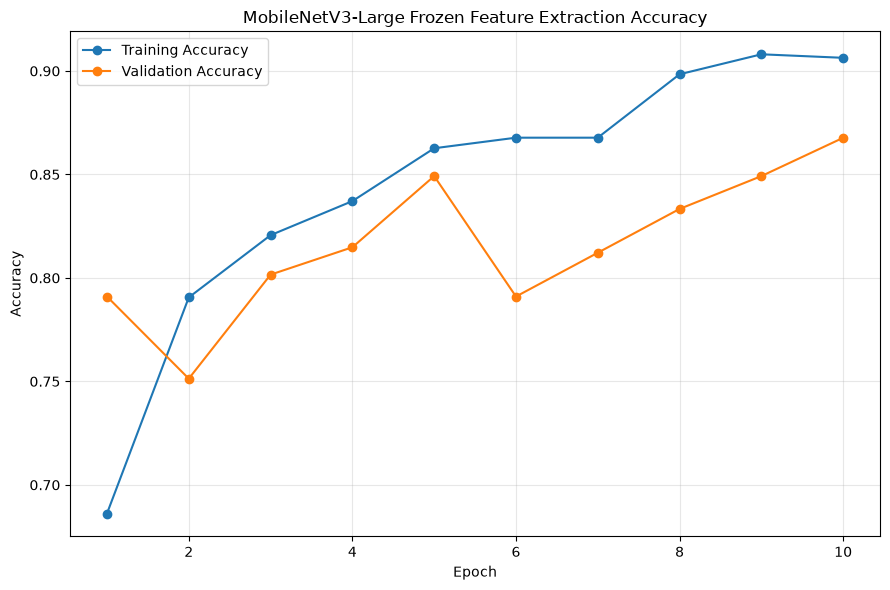

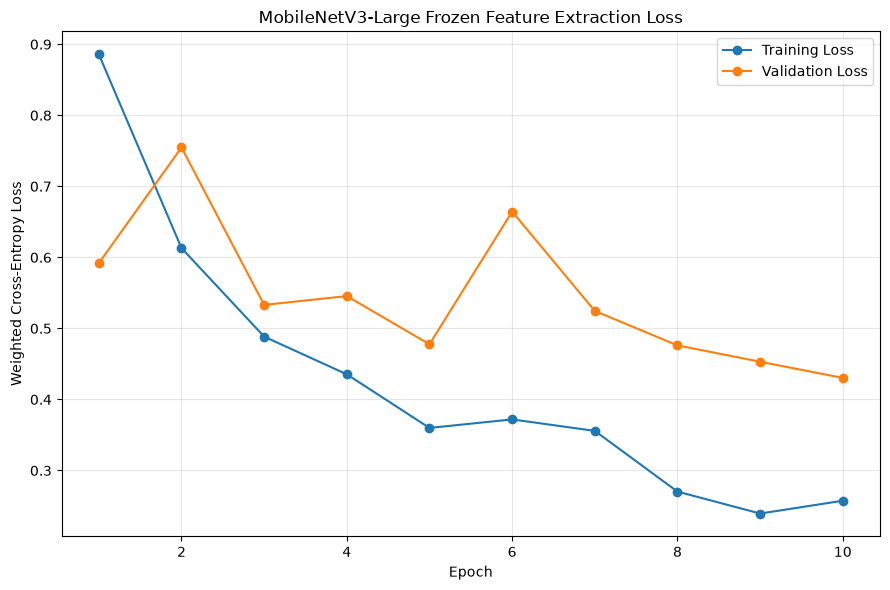

Best frozen epoch: 10
Best frozen validation loss: 0.4303
Best frozen validation accuracy: 0.8677


In [53]:
(
    FROZEN_ACCURACY_FIGURE_PATH,
    FROZEN_LOSS_FIGURE_PATH,
) = plot_training_curves(
    history=frozen_training_history,
    title_prefix=(
        "MobileNetV3-Large Frozen Feature Extraction"
    ),
    file_prefix=(
        "mobilenet_v3_large_frozen"
    ),
)

best_frozen_row = (
    frozen_training_history.loc[
        frozen_training_history[
            "validation_loss"
        ].idxmin()
    ]
)

best_frozen_epoch = int(
    best_frozen_row["epoch"]
)

best_frozen_validation_loss = float(
    best_frozen_row[
        "validation_loss"
    ]
)

best_frozen_validation_accuracy = float(
    best_frozen_row[
        "validation_accuracy"
    ]
)

print(
    f"Best frozen epoch: "
    f"{best_frozen_epoch}"
)

print(
    f"Best frozen validation loss: "
    f"{best_frozen_validation_loss:.4f}"
)

print(
    f"Best frozen validation accuracy: "
    f"{best_frozen_validation_accuracy:.4f}"
)

In [54]:
frozen_checkpoint = torch.load(
    FROZEN_CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)

mobilenet_model.load_state_dict(
    frozen_checkpoint[
        "model_state_dict"
    ]
)

mobilenet_model = (
    mobilenet_model.to(DEVICE)
)

print(
    "Best frozen MobileNetV3-Large "
    "checkpoint restored."
)

Best frozen MobileNetV3-Large checkpoint restored.


In [55]:
for parameter in (
    mobilenet_model.parameters()
):
    parameter.requires_grad = False

for parameter in (
    mobilenet_model.classifier.parameters()
):
    parameter.requires_grad = True

number_of_feature_blocks = len(
    mobilenet_model.features
)

if (
    FINE_TUNE_LAST_N_BLOCKS
    > number_of_feature_blocks
):
    raise ValueError(
        "The requested number of fine-tuned "
        "blocks exceeds the architecture size."
    )

first_trainable_block_index = (
    number_of_feature_blocks
    - FINE_TUNE_LAST_N_BLOCKS
)

for block in (
    mobilenet_model.features[
        first_trainable_block_index:
    ]
):
    for parameter in (
        block.parameters()
    ):
        parameter.requires_grad = True

batch_norm_count = 0

for module in (
    mobilenet_model.modules()
):
    if isinstance(
        module,
        (
            nn.BatchNorm1d,
            nn.BatchNorm2d,
            nn.BatchNorm3d,
        ),
    ):
        batch_norm_count += 1

        for parameter in (
            module.parameters()
        ):
            parameter.requires_grad = False

print(
    f"Total feature blocks       : "
    f"{number_of_feature_blocks}"
)

print(
    f"First trainable block index: "
    f"{first_trainable_block_index}"
)

print(
    f"Fine-tuned feature blocks  : "
    f"{FINE_TUNE_LAST_N_BLOCKS}"
)

print(
    f"Frozen BatchNorm modules   : "
    f"{batch_norm_count}"
)

Total feature blocks       : 17
First trainable block index: 14
Fine-tuned feature blocks  : 3
Frozen BatchNorm modules   : 46


In [56]:
feature_trainability_records = []

for block_index, block in enumerate(
    mobilenet_model.features
):
    total_parameters = sum(
        parameter.numel()
        for parameter
        in block.parameters()
    )

    trainable_parameters = sum(
        parameter.numel()
        for parameter
        in block.parameters()
        if parameter.requires_grad
    )

    feature_trainability_records.append(
        {
            "block_index": (
                block_index
            ),
            "total_parameters": (
                total_parameters
            ),
            "trainable_parameters": (
                trainable_parameters
            ),
            "frozen_parameters": (
                total_parameters
                - trainable_parameters
            ),
            "contains_trainable_parameters": (
                trainable_parameters > 0
            ),
        }
    )

feature_trainability_table = (
    pd.DataFrame(
        feature_trainability_records
    )
)

feature_trainability_table

,block_index,total_parameters,trainable_parameters,frozen_parameters,contains_trainable_parameters
0,0,464,0,464,False
1,1,464,0,464,False
2,2,3440,0,3440,False
3,3,4440,0,4440,False
4,4,10328,0,10328,False
5,5,20992,0,20992,False
6,6,20992,0,20992,False
7,7,32080,0,32080,False
8,8,34760,0,34760,False
9,9,31992,0,31992,False


In [81]:
fine_tuning_parameter_summary = (
    count_model_parameters(
        mobilenet_model
    )
)

trainable_backbone_parameters = [
    parameter
    for parameter
    in mobilenet_model.features.parameters()
    if parameter.requires_grad
]

trainable_classifier_parameters = [
    parameter
    for parameter
    in mobilenet_model.classifier.parameters()
    if parameter.requires_grad
]

if not trainable_backbone_parameters:
    raise RuntimeError(
        "No trainable backbone parameters "
        "were found."
    )

if not trainable_classifier_parameters:
    raise RuntimeError(
        "No trainable classifier parameters "
        "were found."
    )

fine_tuning_criterion = (
    nn.CrossEntropyLoss(
        weight=class_weights.to(
            DEVICE
        )
    )
)

fine_tuning_optimizer = Adam(
    [
        {
            "params": (
                trainable_backbone_parameters
            ),
            "lr": (
                BACKBONE_FINE_TUNE_LEARNING_RATE
            ),
            "name": (
                "upper_feature_blocks"
            ),
        },
        {
            "params": (
                trainable_classifier_parameters
            ),
            "lr": (
                CLASSIFIER_FINE_TUNE_LEARNING_RATE
            ),
            "name": "classifier",
        },
    ],
    weight_decay=WEIGHT_DECAY,
)

fine_tuning_scheduler = (
    ReduceLROnPlateau(
        optimizer=(
            fine_tuning_optimizer
        ),
        mode="min",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
    )
)

print(
    "Fine-tuning optimizer configured."
)

for key, value in (
    fine_tuning_parameter_summary.items()
):
    print(
        f"{key}: {value:,}"
    )

Fine-tuning optimizer configured.
total_parameters: 4,209,718
trainable_parameters: 2,977,766
frozen_parameters: 1,231,952


In [58]:
FINE_TUNING_SMOKE_TEST_PATH = (
    MODEL_DIRECTORY
    / "mobilenet_v3_large_fine_tuning_smoke_test.pt"
)

fine_tuning_smoke_history = (
    run_training_stage(
        model=mobilenet_model,
        train_loader=train_loader,
        validation_loader=(
            validation_loader
        ),
        loss_function=(
            fine_tuning_criterion
        ),
        optimizer=(
            fine_tuning_optimizer
        ),
        scheduler=(
            fine_tuning_scheduler
        ),
        device=DEVICE,
        maximum_epochs=1,
        checkpoint_path=(
            FINE_TUNING_SMOKE_TEST_PATH
        ),
        training_stage=(
            "controlled_fine_tuning_smoke_test"
        ),
        early_stopping_patience=1,
        minimum_improvement=(
            MINIMUM_IMPROVEMENT
        ),
        keep_batch_norm_frozen=True,
    )
)

fine_tuning_smoke_history

Controlled Fine Tuning Smoke Test — Epoch 1/1
Learning rates      : 0.00001000, 0.00010000
Training loss       : 0.0756
Training accuracy   : 0.9756
Validation loss     : 0.4182
Validation accuracy : 0.8783
Epoch duration      : 111.83 seconds
Checkpoint status   : Best checkpoint saved
Early-stop counter  : 0/1
Controlled Fine Tuning Smoke Test completed.
Total duration: 1.86 minutes
Best validation loss: 0.4182


,epoch,learning_rates,train_loss,train_accuracy,validation_loss,validation_accuracy,epoch_duration_seconds,checkpoint_saved
0,1,"0.0000100000,0.0001000000",0.075559,0.975596,0.41825,0.878307,111.833651,True


In [59]:
mobilenet_model.load_state_dict(
    frozen_checkpoint[
        "model_state_dict"
    ]
)

mobilenet_model = (
    mobilenet_model.to(DEVICE)
)

for parameter in (
    mobilenet_model.parameters()
):
    parameter.requires_grad = False

for parameter in (
    mobilenet_model.classifier.parameters()
):
    parameter.requires_grad = True

for block in (
    mobilenet_model.features[
        first_trainable_block_index:
    ]
):
    for parameter in (
        block.parameters()
    ):
        parameter.requires_grad = True

for module in (
    mobilenet_model.modules()
):
    if isinstance(
        module,
        (
            nn.BatchNorm1d,
            nn.BatchNorm2d,
            nn.BatchNorm3d,
        ),
    ):
        for parameter in (
            module.parameters()
        ):
            parameter.requires_grad = False

trainable_backbone_parameters = [
    parameter
    for parameter
    in mobilenet_model.features.parameters()
    if parameter.requires_grad
]

trainable_classifier_parameters = [
    parameter
    for parameter
    in mobilenet_model.classifier.parameters()
    if parameter.requires_grad
]

fine_tuning_criterion = (
    nn.CrossEntropyLoss(
        weight=class_weights.to(
            DEVICE
        )
    )
)

fine_tuning_optimizer = Adam(
    [
        {
            "params": (
                trainable_backbone_parameters
            ),
            "lr": (
                BACKBONE_FINE_TUNE_LEARNING_RATE
            ),
            "name": (
                "upper_feature_blocks"
            ),
        },
        {
            "params": (
                trainable_classifier_parameters
            ),
            "lr": (
                CLASSIFIER_FINE_TUNE_LEARNING_RATE
            ),
            "name": "classifier",
        },
    ],
    weight_decay=WEIGHT_DECAY,
)

fine_tuning_scheduler = (
    ReduceLROnPlateau(
        optimizer=(
            fine_tuning_optimizer
        ),
        mode="min",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
    )
)

print(
    "Clean MobileNetV3-Large "
    "fine-tuning state restored."
)

Clean MobileNetV3-Large fine-tuning state restored.


In [60]:
fine_tuning_history = (
    run_training_stage(
        model=mobilenet_model,
        train_loader=train_loader,
        validation_loader=(
            validation_loader
        ),
        loss_function=(
            fine_tuning_criterion
        ),
        optimizer=(
            fine_tuning_optimizer
        ),
        scheduler=(
            fine_tuning_scheduler
        ),
        device=DEVICE,
        maximum_epochs=(
            FINE_TUNE_EPOCHS
        ),
        checkpoint_path=(
            FINE_TUNED_CHECKPOINT_PATH
        ),
        training_stage=(
            "controlled_fine_tuning"
        ),
        early_stopping_patience=(
            EARLY_STOPPING_PATIENCE
        ),
        minimum_improvement=(
            MINIMUM_IMPROVEMENT
        ),
        keep_batch_norm_frozen=True,
    )
)

fine_tuning_history

Controlled Fine Tuning — Epoch 1/5
Learning rates      : 0.00001000, 0.00010000
Training loss       : 0.0839
Training accuracy   : 0.9711
Validation loss     : 0.4208
Validation accuracy : 0.8730
Epoch duration      : 105.32 seconds
Checkpoint status   : Best checkpoint saved
Early-stop counter  : 0/5
Controlled Fine Tuning — Epoch 2/5
Learning rates      : 0.00001000, 0.00010000
Training loss       : 0.0513
Training accuracy   : 0.9847
Validation loss     : 0.4077
Validation accuracy : 0.8757
Epoch duration      : 113.23 seconds
Checkpoint status   : Best checkpoint saved
Early-stop counter  : 0/5
Controlled Fine Tuning — Epoch 3/5
Learning rates      : 0.00001000, 0.00010000
Training loss       : 0.0425
Training accuracy   : 0.9869
Validation loss     : 0.4227
Validation accuracy : 0.8757
Epoch duration      : 105.50 seconds
Checkpoint status   : No validation improvement
Early-stop counter  : 1/5
Controlled Fine Tuning — Epoch 4/5
Learning rates      : 0.00001000, 0.00010000
Trainin

,epoch,learning_rates,train_loss,train_accuracy,validation_loss,validation_accuracy,epoch_duration_seconds,checkpoint_saved
0,1,"0.0000100000,0.0001000000",0.083886,0.971056,0.420765,0.873016,105.324145,True
1,2,"0.0000100000,0.0001000000",0.051266,0.984677,0.407661,0.875661,113.232041,True
2,3,"0.0000100000,0.0001000000",0.042477,0.986947,0.422725,0.875661,105.497606,False
3,4,"0.0000100000,0.0001000000",0.034446,0.991487,0.452715,0.878307,110.116717,False
4,5,"0.0000100000,0.0001000000",0.037989,0.986947,0.413838,0.880952,113.077618,False


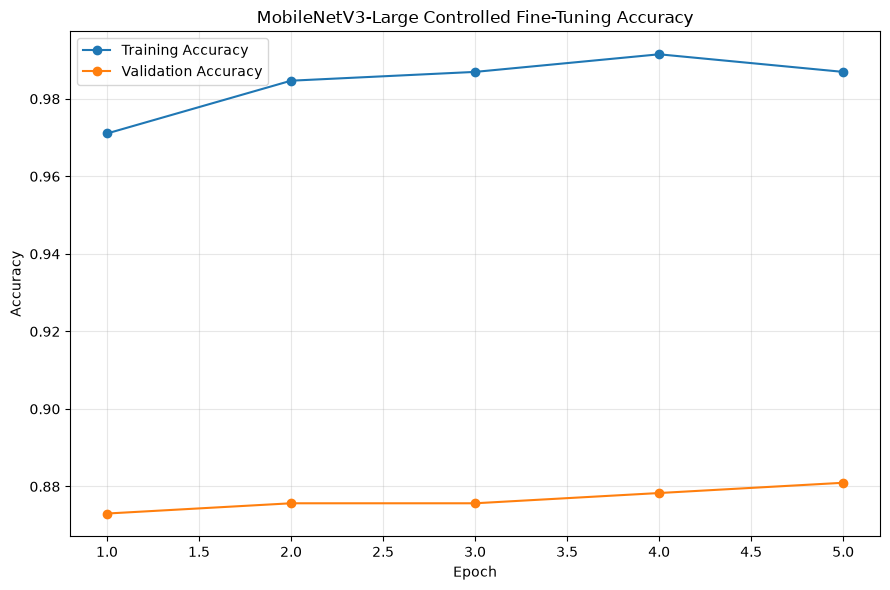

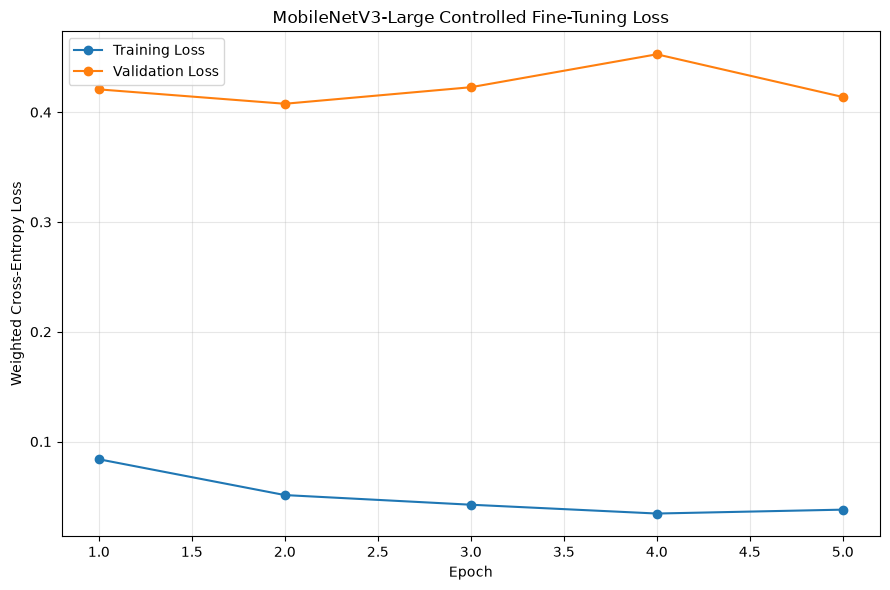

In [61]:
FINE_TUNING_HISTORY_PATH = (
    LOGS_DIRECTORY
    / "mobilenet_v3_large_fine_tuning_history.csv"
)

fine_tuning_history.to_csv(
    FINE_TUNING_HISTORY_PATH,
    index=False,
)

(
    FINE_TUNING_ACCURACY_FIGURE_PATH,
    FINE_TUNING_LOSS_FIGURE_PATH,
) = plot_training_curves(
    history=fine_tuning_history,
    title_prefix=(
        "MobileNetV3-Large Controlled Fine-Tuning"
    ),
    file_prefix=(
        "mobilenet_v3_large_fine_tuning"
    ),
)

In [62]:
best_fine_tuning_row = (
    fine_tuning_history.loc[
        fine_tuning_history[
            "validation_loss"
        ].idxmin()
    ]
)

best_fine_tuning_epoch = int(
    best_fine_tuning_row["epoch"]
)

best_fine_tuning_validation_loss = float(
    best_fine_tuning_row[
        "validation_loss"
    ]
)

best_fine_tuning_validation_accuracy = float(
    best_fine_tuning_row[
        "validation_accuracy"
    ]
)

validation_accuracy_change = (
    best_fine_tuning_validation_accuracy
    - best_frozen_validation_accuracy
)

validation_loss_change = (
    best_fine_tuning_validation_loss
    - best_frozen_validation_loss
)

validation_comparison = pd.DataFrame(
    [
        {
            "training_stage": (
                "Frozen feature extraction"
            ),
            "best_epoch": (
                best_frozen_epoch
            ),
            "validation_loss": (
                best_frozen_validation_loss
            ),
            "validation_accuracy": (
                best_frozen_validation_accuracy
            ),
        },
        {
            "training_stage": (
                "Controlled fine-tuning"
            ),
            "best_epoch": (
                best_fine_tuning_epoch
            ),
            "validation_loss": (
                best_fine_tuning_validation_loss
            ),
            "validation_accuracy": (
                best_fine_tuning_validation_accuracy
            ),
        },
    ]
)

display(
    validation_comparison
)

print(
    f"Validation accuracy change: "
    f"{validation_accuracy_change:+.4f}"
)

print(
    f"Validation loss change: "
    f"{validation_loss_change:+.4f}"
)

,training_stage,best_epoch,validation_loss,validation_accuracy
0,Frozen feature extraction,10,0.430331,0.867725
1,Controlled fine-tuning,2,0.407661,0.875661


Validation accuracy change: +0.0079
Validation loss change: -0.0227


In [63]:
def build_mobilenet_v3_large_model(
    number_of_classes: int,
    dropout_rate: float,
    device: torch.device,
) -> nn.Module:
    """
    Build MobileNetV3-Large with a TrashNet classifier.
    """
    model = mobilenet_v3_large(
        weights=None
    )

    classifier_input_features = (
        model.classifier[3]
        .in_features
    )

    model.classifier[2] = (
        nn.Dropout(
            p=dropout_rate,
            inplace=True,
        )
    )

    model.classifier[3] = (
        nn.Linear(
            in_features=(
                classifier_input_features
            ),
            out_features=(
                number_of_classes
            ),
        )
    )

    return model.to(device)

In [64]:
final_mobilenet_model = (
    build_mobilenet_v3_large_model(
        number_of_classes=(
            NUM_CLASSES
        ),
        dropout_rate=(
            DROPOUT_RATE
        ),
        device=DEVICE,
    )
)

final_checkpoint = torch.load(
    FINE_TUNED_CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)

final_mobilenet_model.load_state_dict(
    final_checkpoint[
        "model_state_dict"
    ]
)

final_mobilenet_model.eval()

if (
    final_checkpoint["architecture"]
    != "mobilenet_v3_large"
):
    raise ValueError(
        "The loaded checkpoint does not "
        "contain MobileNetV3-Large."
    )

if (
    final_checkpoint["class_names"]
    != class_names
):
    raise ValueError(
        "Checkpoint class names do not match."
    )

if (
    final_checkpoint["class_to_index"]
    != class_to_index
):
    raise ValueError(
        "Checkpoint class mapping does not match."
    )

if tuple(
    final_checkpoint["image_size"]
) != tuple(IMAGE_SIZE):
    raise ValueError(
        "Checkpoint image size does not match."
    )

print(
    "Final MobileNetV3-Large checkpoint "
    "loaded and verified successfully."
)

Final MobileNetV3-Large checkpoint loaded and verified successfully.


In [65]:
def collect_predictions(
    model: nn.Module,
    data_loader: DataLoader,
    loss_function: nn.Module,
    device: torch.device,
) -> dict:
    """
    Evaluate a classification model and collect predictions.
    """
    model.eval()

    running_loss = 0.0
    sample_count = 0

    true_labels = []
    predicted_labels = []
    probability_batches = []
    image_paths = []

    start_time = (
        time.perf_counter()
    )

    with torch.inference_mode():
        for batch in data_loader:
            images = batch["image"].to(
                device,
                non_blocking=True,
            )

            labels = batch["label"].to(
                device,
                non_blocking=True,
            )

            logits = model(images)

            loss = loss_function(
                logits,
                labels,
            )

            probabilities = (
                torch.softmax(
                    logits,
                    dim=1,
                )
            )

            predictions = (
                torch.argmax(
                    probabilities,
                    dim=1,
                )
            )

            batch_size = labels.size(0)

            running_loss += (
                loss.item()
                * batch_size
            )

            sample_count += batch_size

            true_labels.extend(
                labels.cpu().tolist()
            )

            predicted_labels.extend(
                predictions.cpu().tolist()
            )

            probability_batches.append(
                probabilities
                .cpu()
                .numpy()
            )

            image_paths.extend(
                list(batch["path"])
            )

    if sample_count == 0:
        raise RuntimeError(
            "The evaluation DataLoader "
            "returned no samples."
        )

    duration_seconds = (
        time.perf_counter()
        - start_time
    )

    return {
        "loss": float(
            running_loss
            / sample_count
        ),
        "sample_count": int(
            sample_count
        ),
        "true_labels": np.asarray(
            true_labels,
            dtype=np.int64,
        ),
        "predicted_labels": np.asarray(
            predicted_labels,
            dtype=np.int64,
        ),
        "probabilities": np.concatenate(
            probability_batches,
            axis=0,
        ),
        "image_paths": image_paths,
        "duration_seconds": float(
            duration_seconds
        ),
    }

In [66]:
final_criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(DEVICE)
)

test_output = collect_predictions(
    model=final_mobilenet_model,
    data_loader=test_loader,
    loss_function=final_criterion,
    device=DEVICE,
)

test_loss = test_output["loss"]

true_labels = test_output[
    "true_labels"
]

predicted_labels = test_output[
    "predicted_labels"
]

prediction_probabilities = (
    test_output["probabilities"]
)

test_image_paths = test_output[
    "image_paths"
]

test_evaluation_duration_seconds = (
    test_output[
        "duration_seconds"
    ]
)

print(
    f"Test samples    : "
    f"{len(true_labels)}"
)

print(
    f"Test loss       : "
    f"{test_loss:.4f}"
)

print(
    f"Evaluation time : "
    f"{test_evaluation_duration_seconds:.2f} seconds"
)

Test samples    : 381
Test loss       : 0.4070
Evaluation time : 14.16 seconds


In [67]:
test_accuracy = accuracy_score(
    true_labels,
    predicted_labels,
)

(
    weighted_precision,
    weighted_recall,
    weighted_f1,
    _,
) = precision_recall_fscore_support(
    true_labels,
    predicted_labels,
    labels=range(NUM_CLASSES),
    average="weighted",
    zero_division=0,
)

(
    macro_precision,
    macro_recall,
    macro_f1,
    _,
) = precision_recall_fscore_support(
    true_labels,
    predicted_labels,
    labels=range(NUM_CLASSES),
    average="macro",
    zero_division=0,
)

print("=" * 72)
print(
    "MOBILENETV3-LARGE TEST METRICS"
)
print("=" * 72)

print(
    f"Test loss          : "
    f"{test_loss:.4f}"
)

print(
    f"Test accuracy      : "
    f"{test_accuracy:.4f}"
)

print(
    f"Weighted precision : "
    f"{weighted_precision:.4f}"
)

print(
    f"Weighted recall    : "
    f"{weighted_recall:.4f}"
)

print(
    f"Weighted F1-score  : "
    f"{weighted_f1:.4f}"
)

print(
    f"Macro precision    : "
    f"{macro_precision:.4f}"
)

print(
    f"Macro recall       : "
    f"{macro_recall:.4f}"
)

print(
    f"Macro F1-score     : "
    f"{macro_f1:.4f}"
)

print("=" * 72)

MOBILENETV3-LARGE TEST METRICS
Test loss          : 0.4070
Test accuracy      : 0.8819
Weighted precision : 0.8843
Weighted recall    : 0.8819
Weighted F1-score  : 0.8815
Macro precision    : 0.8806
Macro recall       : 0.8644
Macro F1-score     : 0.8706


In [68]:
classification_report_dictionary = (
    classification_report(
        true_labels,
        predicted_labels,
        labels=range(NUM_CLASSES),
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
)

classification_report_dataframe = (
    pd.DataFrame(
        classification_report_dictionary
    ).transpose()
)

CLASSIFICATION_REPORT_PATH = (
    RESULTS_DIRECTORY
    / "mobilenet_v3_large_classification_report.csv"
)

classification_report_dataframe.to_csv(
    CLASSIFICATION_REPORT_PATH,
    index=True,
)

classification_report_dataframe

,precision,recall,f1-score,support
cardboard,0.903226,0.918033,0.910569,61.00000
glass,0.938462,0.813333,0.871429,75.00000
metal,0.936508,0.951613,0.944000,62.00000
paper,0.861702,0.900000,0.880435,90.00000
plastic,0.810127,0.888889,0.847682,72.00000
trash,0.833333,0.714286,0.769231,21.00000
accuracy,0.881890,0.881890,0.881890,0.88189
macro avg,0.880560,0.864359,0.870558,381.00000
weighted avg,0.884323,0.881890,0.881512,381.00000


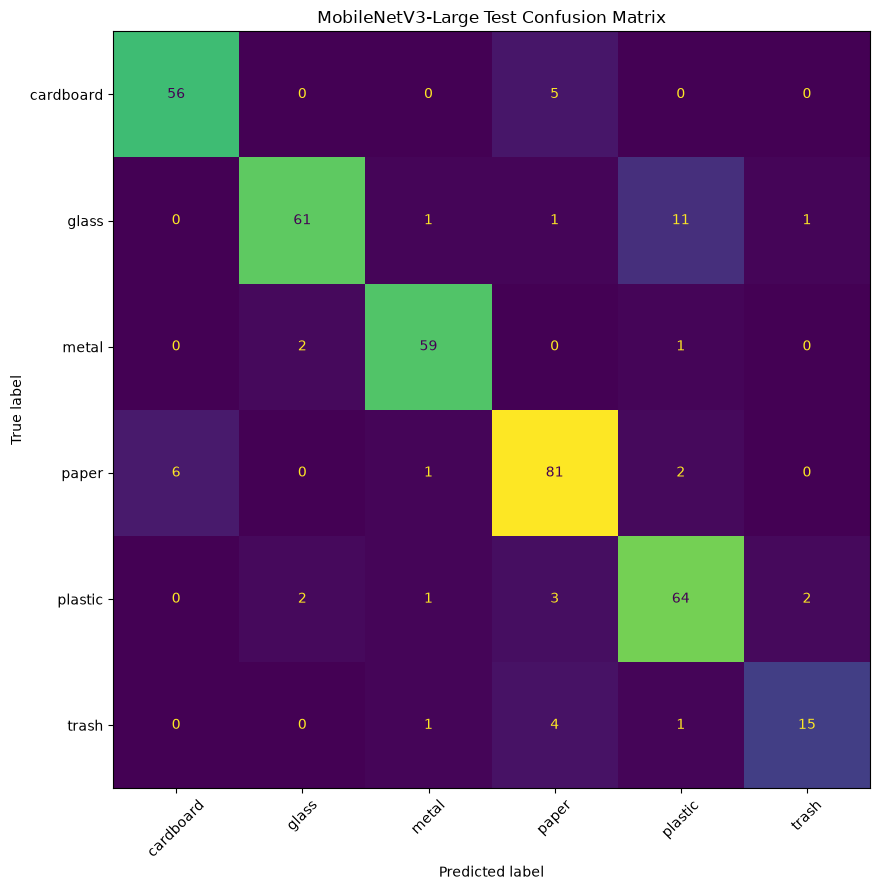

In [69]:
confusion_matrix_values = (
    confusion_matrix(
        true_labels,
        predicted_labels,
        labels=range(NUM_CLASSES),
    )
)

confusion_matrix_dataframe = (
    pd.DataFrame(
        confusion_matrix_values,
        index=class_names,
        columns=class_names,
    )
)

CONFUSION_MATRIX_CSV_PATH = (
    RESULTS_DIRECTORY
    / "mobilenet_v3_large_confusion_matrix.csv"
)

confusion_matrix_dataframe.to_csv(
    CONFUSION_MATRIX_CSV_PATH
)

figure, axis = plt.subplots(
    figsize=(10, 9)
)

ConfusionMatrixDisplay(
    confusion_matrix=(
        confusion_matrix_values
    ),
    display_labels=class_names,
).plot(
    ax=axis,
    values_format="d",
    xticks_rotation=45,
    colorbar=False,
)

plt.title(
    "MobileNetV3-Large Test Confusion Matrix"
)

plt.tight_layout()

CONFUSION_MATRIX_FIGURE_PATH = (
    FIGURES_DIRECTORY
    / "mobilenet_v3_large_test_confusion_matrix.png"
)

plt.savefig(
    CONFUSION_MATRIX_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [70]:
class_test_counts = (
    confusion_matrix_values.sum(
        axis=1
    )
)

class_correct_counts = (
    np.diag(
        confusion_matrix_values
    )
)

per_class_accuracy = np.divide(
    class_correct_counts,
    class_test_counts,
    out=np.zeros_like(
        class_correct_counts,
        dtype=float,
    ),
    where=(
        class_test_counts != 0
    ),
)

per_class_results = pd.DataFrame(
    {
        "class_name": class_names,
        "test_samples": (
            class_test_counts
        ),
        "correct_predictions": (
            class_correct_counts
        ),
        "per_class_accuracy": (
            per_class_accuracy
        ),
        "precision": [
            classification_report_dictionary[
                class_name
            ]["precision"]
            for class_name
            in class_names
        ],
        "recall": [
            classification_report_dictionary[
                class_name
            ]["recall"]
            for class_name
            in class_names
        ],
        "f1_score": [
            classification_report_dictionary[
                class_name
            ]["f1-score"]
            for class_name
            in class_names
        ],
    }
)

PER_CLASS_RESULTS_PATH = (
    RESULTS_DIRECTORY
    / "mobilenet_v3_large_per_class_results.csv"
)

per_class_results.to_csv(
    PER_CLASS_RESULTS_PATH,
    index=False,
)

per_class_results

,class_name,test_samples,correct_predictions,per_class_accuracy,precision,recall,f1_score
0,cardboard,61,56,0.918033,0.903226,0.918033,0.910569
1,glass,75,61,0.813333,0.938462,0.813333,0.871429
2,metal,62,59,0.951613,0.936508,0.951613,0.944000
3,paper,90,81,0.900000,0.861702,0.900000,0.880435
4,plastic,72,64,0.888889,0.810127,0.888889,0.847682
5,trash,21,15,0.714286,0.833333,0.714286,0.769231


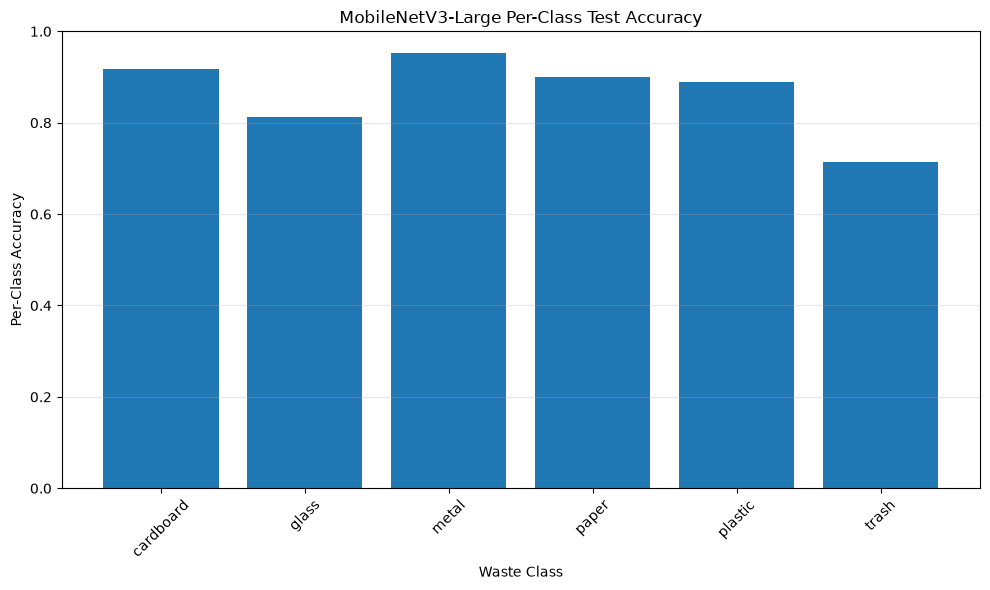

In [71]:
plt.figure(
    figsize=(10, 6)
)

plt.bar(
    per_class_results[
        "class_name"
    ],
    per_class_results[
        "per_class_accuracy"
    ],
)

plt.ylim(0, 1)
plt.xlabel("Waste Class")
plt.ylabel(
    "Per-Class Accuracy"
)
plt.title(
    "MobileNetV3-Large Per-Class Test Accuracy"
)

plt.xticks(
    rotation=45
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

PER_CLASS_ACCURACY_FIGURE_PATH = (
    FIGURES_DIRECTORY
    / "mobilenet_v3_large_per_class_accuracy.png"
)

plt.savefig(
    PER_CLASS_ACCURACY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [72]:
prediction_confidences = (
    prediction_probabilities.max(
        axis=1
    )
)

prediction_results = pd.DataFrame(
    {
        "image_path": (
            test_image_paths
        ),
        "true_class_index": (
            true_labels
        ),
        "predicted_class_index": (
            predicted_labels
        ),
        "true_class": [
            index_to_class[
                int(label)
            ]
            for label
            in true_labels
        ],
        "predicted_class": [
            index_to_class[
                int(label)
            ]
            for label
            in predicted_labels
        ],
        "confidence": (
            prediction_confidences
        ),
        "correct": (
            true_labels
            == predicted_labels
        ),
    }
)

for class_index, class_name in enumerate(
    class_names
):
    prediction_results[
        f"probability_{class_name}"
    ] = (
        prediction_probabilities[
            :,
            class_index,
        ]
    )

PREDICTION_RESULTS_PATH = (
    RESULTS_DIRECTORY
    / "mobilenet_v3_large_test_predictions.csv"
)

prediction_results.to_csv(
    PREDICTION_RESULTS_PATH,
    index=False,
)

prediction_results.head()

,image_path,true_class_index,predicted_class_index,true_class,predicted_class,confidence,correct,probability_cardboard,probability_glass,probability_metal,probability_paper,probability_plastic,probability_trash
0,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,0,0,cardboard,cardboard,1.000000,True,1.000000,3.220110e-13,1.190734e-12,2.436154e-08,1.029229e-12,1.562807e-11
1,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,0,0,cardboard,cardboard,1.000000,True,1.000000,1.178911e-10,1.719772e-09,2.928676e-08,3.230707e-11,7.995318e-10
2,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,0,0,cardboard,cardboard,0.524929,True,0.524929,2.606957e-03,9.840338e-04,4.712164e-01,2.635902e-04,1.090732e-07
3,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,0,0,cardboard,cardboard,0.967045,True,0.967045,8.908523e-06,1.359998e-06,3.283315e-02,3.439755e-05,7.748991e-05
4,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,0,0,cardboard,cardboard,0.999998,True,0.999998,9.629829e-08,1.936205e-08,1.960272e-06,1.449142e-08,4.537778e-08


In [73]:
incorrect_predictions = (
    prediction_results[
        prediction_results[
            "correct"
        ] == False
    ]
    .copy()
    .sort_values(
        "confidence",
        ascending=False,
    )
    .reset_index(drop=True)
)

correct_predictions = (
    prediction_results[
        prediction_results[
            "correct"
        ] == True
    ]
    .copy()
    .sort_values(
        "confidence",
        ascending=True,
    )
    .reset_index(drop=True)
)

highest_confidence_errors = (
    incorrect_predictions.head(20)
)

HIGH_CONFIDENCE_ERRORS_PATH = (
    RESULTS_DIRECTORY
    / "mobilenet_v3_large_high_confidence_errors.csv"
)

highest_confidence_errors.to_csv(
    HIGH_CONFIDENCE_ERRORS_PATH,
    index=False,
)

print(
    f"Correct predictions  : "
    f"{len(correct_predictions)}"
)

print(
    f"Incorrect predictions: "
    f"{len(incorrect_predictions)}"
)

print(
    f"Error rate           : "
    f"{len(incorrect_predictions) / len(prediction_results):.4f}"
)

Correct predictions  : 336
Incorrect predictions: 45
Error rate           : 0.1181


In [74]:
confusion_records = []

for true_index in range(
    NUM_CLASSES
):
    for predicted_index in range(
        NUM_CLASSES
    ):
        if (
            true_index
            == predicted_index
        ):
            continue

        confusion_records.append(
            {
                "true_class": (
                    class_names[
                        true_index
                    ]
                ),
                "predicted_class": (
                    class_names[
                        predicted_index
                    ]
                ),
                "error_count": int(
                    confusion_matrix_values[
                        true_index,
                        predicted_index,
                    ]
                ),
            }
        )

class_confusions = (
    pd.DataFrame(
        confusion_records
    )
    .sort_values(
        "error_count",
        ascending=False,
    )
    .reset_index(drop=True)
)

CLASS_CONFUSIONS_PATH = (
    RESULTS_DIRECTORY
    / "mobilenet_v3_large_class_confusions.csv"
)

class_confusions.to_csv(
    CLASS_CONFUSIONS_PATH,
    index=False,
)

class_confusions.head(15)

,true_class,predicted_class,error_count
0,glass,plastic,11
1,paper,cardboard,6
2,cardboard,paper,5
3,trash,paper,4
4,plastic,paper,3
5,metal,glass,2
6,paper,plastic,2
7,plastic,glass,2
8,plastic,trash,2
9,plastic,metal,1


In [75]:
confidence_summary = (
    prediction_results
    .groupby(
        "correct"
    )["confidence"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "min",
            "max",
            "std",
        ]
    )
)

confidence_summary.index = (
    confidence_summary.index.map(
        {
            False: "Incorrect",
            True: "Correct",
        }
    )
)

display(
    confidence_summary
)

true_distribution = (
    prediction_results[
        "true_class"
    ]
    .value_counts()
    .reindex(
        class_names,
        fill_value=0,
    )
)

predicted_distribution = (
    prediction_results[
        "predicted_class"
    ]
    .value_counts()
    .reindex(
        class_names,
        fill_value=0,
    )
)

distribution_comparison = (
    pd.DataFrame(
        {
            "true_count": (
                true_distribution
            ),
            "predicted_count": (
                predicted_distribution
            ),
        }
    )
)

distribution_comparison[
    "count_difference"
] = (
    distribution_comparison[
        "predicted_count"
    ]
    - distribution_comparison[
        "true_count"
    ]
)

DISTRIBUTION_COMPARISON_PATH = (
    RESULTS_DIRECTORY
    / "mobilenet_v3_large_prediction_distribution.csv"
)

distribution_comparison.to_csv(
    DISTRIBUTION_COMPARISON_PATH
)

distribution_comparison

,count,mean,median,min,max,std
correct,,,,,,
Incorrect,45,0.749540,0.716477,0.436720,0.999935,0.192353
Correct,336,0.956366,0.997960,0.393456,1.000000,0.099131


,true_count,predicted_count,count_difference
cardboard,61,62,1
glass,75,65,-10
metal,62,63,1
paper,90,94,4
plastic,72,79,7
trash,21,18,-3


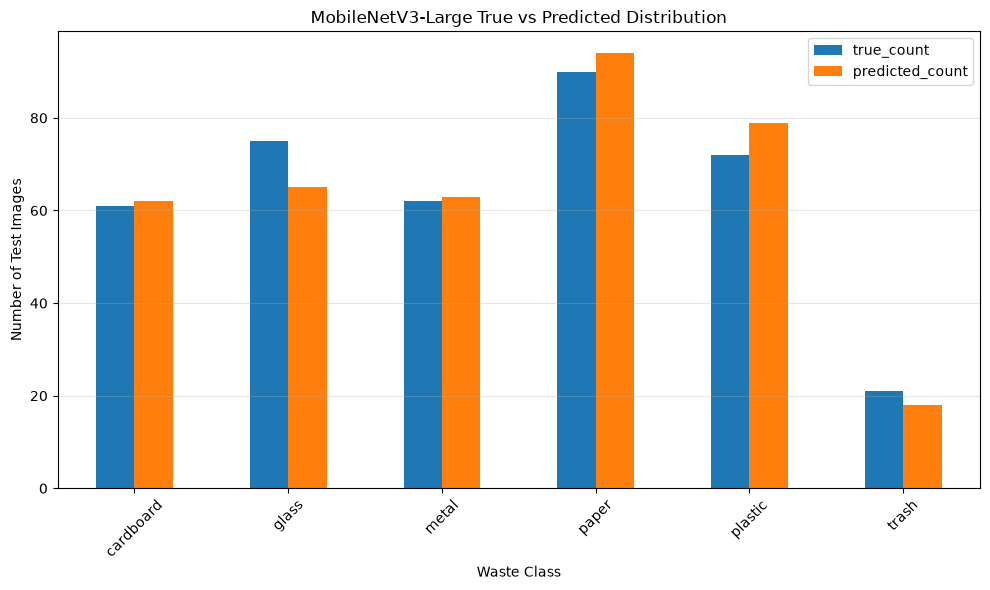

In [76]:
distribution_comparison[
    [
        "true_count",
        "predicted_count",
    ]
].plot(
    kind="bar",
    figsize=(10, 6),
)

plt.xlabel("Waste Class")
plt.ylabel(
    "Number of Test Images"
)
plt.title(
    "MobileNetV3-Large True vs Predicted Distribution"
)

plt.xticks(
    rotation=45
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

PREDICTION_DISTRIBUTION_FIGURE_PATH = (
    FIGURES_DIRECTORY
    / "mobilenet_v3_large_prediction_distribution.png"
)

plt.savefig(
    PREDICTION_DISTRIBUTION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [77]:
strongest_class_record = (
    per_class_results.loc[
        per_class_results[
            "per_class_accuracy"
        ].idxmax()
    ]
)

weakest_class_record = (
    per_class_results.loc[
        per_class_results[
            "per_class_accuracy"
        ].idxmin()
    ]
)

non_zero_confusions = (
    class_confusions[
        class_confusions[
            "error_count"
        ] > 0
    ]
)

most_frequent_confusion = (
    non_zero_confusions.iloc[0]
    if not non_zero_confusions.empty
    else None
)

mean_correct_confidence = (
    float(
        correct_predictions[
            "confidence"
        ].mean()
    )
    if len(correct_predictions) > 0
    else None
)

mean_incorrect_confidence = (
    float(
        incorrect_predictions[
            "confidence"
        ].mean()
    )
    if len(incorrect_predictions) > 0
    else None
)

print(
    "Strongest class:",
    strongest_class_record[
        "class_name"
    ],
)

print(
    "Weakest class:",
    weakest_class_record[
        "class_name"
    ],
)

if most_frequent_confusion is not None:
    print(
        "Most frequent confusion:",
        most_frequent_confusion[
            "true_class"
        ],
        "→",
        most_frequent_confusion[
            "predicted_class"
        ],
        "Count:",
        int(
            most_frequent_confusion[
                "error_count"
            ]
        ),
    )

Strongest class: metal
Weakest class: trash
Most frequent confusion: glass → plastic Count: 11


##  Deployment Model Package

The training checkpoint contains optimizer state and is larger than necessary
for production inference.

A separate inference-only package stores:

- Model weights
- Architecture
- Class mapping
- Image size
- Normalization values
- Dropout rate
- Model version

This package can later be loaded by FastAPI.

In [78]:
deployment_package = {
    "architecture": (
        "mobilenet_v3_large"
    ),
    "model_variant": "large",
    "model_version": (
        MODEL_VERSION
    ),
    "model_state_dict": (
        final_mobilenet_model
        .state_dict()
    ),
    "class_names": list(
        class_names
    ),
    "class_to_index": dict(
        class_to_index
    ),
    "number_of_classes": (
        NUM_CLASSES
    ),
    "image_size": list(
        IMAGE_SIZE
    ),
    "normalization_mean": (
        IMAGENET_MEAN
    ),
    "normalization_std": (
        IMAGENET_STANDARD_DEVIATION
    ),
    "dropout_rate": (
        DROPOUT_RATE
    ),
    "saved_at": (
        datetime.now().isoformat()
    ),
}

torch.save(
    deployment_package,
    DEPLOYMENT_MODEL_PATH,
)

model_size_mb = (
    DEPLOYMENT_MODEL_PATH
    .stat()
    .st_size
    / (1024 ** 2)
)

training_checkpoint_size_mb = (
    FINE_TUNED_CHECKPOINT_PATH
    .stat()
    .st_size
    / (1024 ** 2)
)

print(
    f"Inference-only model size: "
    f"{model_size_mb:.2f} MB"
)

print(
    f"Training checkpoint size: "
    f"{training_checkpoint_size_mb:.2f} MB"
)

print(
    DEPLOYMENT_MODEL_PATH.resolve()
)

Inference-only model size: 16.26 MB
Training checkpoint size: 38.99 MB
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\models\mobilenet_v3_large_deployment.pt


In [79]:
latency_batch = next(
    iter(test_loader)
)

latency_image = (
    latency_batch["image"][:1]
    .to(DEVICE)
)

WARM_UP_RUNS = 5
LATENCY_RUNS = 100

final_mobilenet_model.eval()

with torch.inference_mode():
    for _ in range(
        WARM_UP_RUNS
    ):
        _ = final_mobilenet_model(
            latency_image
        )

latency_measurements_ms = []

with torch.inference_mode():
    for _ in range(
        LATENCY_RUNS
    ):
        start_time = (
            time.perf_counter()
        )

        _ = final_mobilenet_model(
            latency_image
        )

        end_time = (
            time.perf_counter()
        )

        latency_measurements_ms.append(
            (
                end_time
                - start_time
            )
            * 1000
        )

mean_latency_ms = float(
    np.mean(
        latency_measurements_ms
    )
)

median_latency_ms = float(
    np.median(
        latency_measurements_ms
    )
)

latency_standard_deviation_ms = float(
    np.std(
        latency_measurements_ms
    )
)

latency_95th_percentile_ms = float(
    np.percentile(
        latency_measurements_ms,
        95,
    )
)

predictions_per_second = (
    1000 / mean_latency_ms
)

print(
    f"Mean latency           : "
    f"{mean_latency_ms:.2f} ms"
)

print(
    f"Median latency         : "
    f"{median_latency_ms:.2f} ms"
)

print(
    f"Latency standard dev.  : "
    f"{latency_standard_deviation_ms:.2f} ms"
)

print(
    f"95th-percentile latency: "
    f"{latency_95th_percentile_ms:.2f} ms"
)

print(
    f"Predictions per second : "
    f"{predictions_per_second:.2f}"
)

Mean latency           : 26.88 ms
Median latency         : 25.56 ms
Latency standard dev.  : 6.75 ms
95th-percentile latency: 39.27 ms
Predictions per second : 37.21


In [82]:
from sklearn.metrics import roc_auc_score

true_labels_one_hot = np.eye(NUM_CLASSES)[true_labels]

macro_roc_auc = None
weighted_roc_auc = None

try:
    macro_roc_auc = roc_auc_score(
        true_labels_one_hot,
        prediction_probabilities,
        multi_class="ovr",
        average="macro",
    )

    weighted_roc_auc = roc_auc_score(
        true_labels_one_hot,
        prediction_probabilities,
        multi_class="ovr",
        average="weighted",
    )

    print(f"Macro ROC-AUC: {macro_roc_auc:.4f}")
    print(f"Weighted ROC-AUC: {weighted_roc_auc:.4f}")

except Exception as e:
    print("ROC calculation failed:")
    print(e)

Macro ROC-AUC: 0.9872
Weighted ROC-AUC: 0.9865


In [83]:
final_parameter_summary = (
    count_model_parameters(
        final_mobilenet_model
    )
)

most_frequent_confusion_record = None

if most_frequent_confusion is not None:
    most_frequent_confusion_record = {
        "true_class": str(
            most_frequent_confusion[
                "true_class"
            ]
        ),
        "predicted_class": str(
            most_frequent_confusion[
                "predicted_class"
            ]
        ),
        "count": int(
            most_frequent_confusion[
                "error_count"
            ]
        ),
    }

mobilenet_final_results = {
    "experiment": {
        "experiment_name": (
            EXPERIMENT_NAME
        ),
        "architecture": (
            "mobilenet_v3_large"
        ),
        "model_variant": "large",
        "model_version": (
            MODEL_VERSION
        ),
        "framework": "PyTorch",
        "pytorch_version": (
            torch.__version__
        ),
        "torchvision_version": (
            torchvision.__version__
        ),
        "device": str(DEVICE),
        "completed_at": (
            datetime.now().isoformat()
        ),
    },

    "dataset": {
        "training_images": len(
            train_dataset
        ),
        "validation_images": len(
            validation_dataset
        ),
        "test_images": len(
            test_dataset
        ),
        "number_of_classes": (
            NUM_CLASSES
        ),
        "class_names": (
            class_names
        ),
        "image_size": list(
            IMAGE_SIZE
        ),
    },

    "frozen_stage": {
        "best_epoch": (
            best_frozen_epoch
        ),
        "best_validation_loss": (
            best_frozen_validation_loss
        ),
        "best_validation_accuracy": (
            best_frozen_validation_accuracy
        ),
        "learning_rate": (
            HEAD_LEARNING_RATE
        ),
    },

    "fine_tuning_stage": {
        "fine_tuned_feature_blocks": (
            FINE_TUNE_LAST_N_BLOCKS
        ),
        "first_trainable_block_index": (
            first_trainable_block_index
        ),
        "batch_normalization_frozen": (
            True
        ),
        "backbone_learning_rate": (
            BACKBONE_FINE_TUNE_LEARNING_RATE
        ),
        "classifier_learning_rate": (
            CLASSIFIER_FINE_TUNE_LEARNING_RATE
        ),
        "best_epoch": (
            best_fine_tuning_epoch
        ),
        "best_validation_loss": (
            best_fine_tuning_validation_loss
        ),
        "best_validation_accuracy": (
            best_fine_tuning_validation_accuracy
        ),
    },

    "test_metrics": {
        "loss": float(
            test_loss
        ),
        "accuracy": float(
            test_accuracy
        ),
        "weighted_precision": float(
            weighted_precision
        ),
        "weighted_recall": float(
            weighted_recall
        ),
        "weighted_f1_score": float(
            weighted_f1
        ),
        "macro_precision": float(
            macro_precision
        ),
        "macro_recall": float(
            macro_recall
        ),
        "macro_f1_score": float(
            macro_f1
        ),
        "macro_roc_auc": (
            float(macro_roc_auc)
            if macro_roc_auc
            is not None
            else None
        ),
        "weighted_roc_auc": (
            float(weighted_roc_auc)
            if weighted_roc_auc
            is not None
            else None
        ),
    },

    "class_analysis": {
        "strongest_class": {
            "class_name": str(
                strongest_class_record[
                    "class_name"
                ]
            ),
            "per_class_accuracy": float(
                strongest_class_record[
                    "per_class_accuracy"
                ]
            ),
        },
        "weakest_class": {
            "class_name": str(
                weakest_class_record[
                    "class_name"
                ]
            ),
            "per_class_accuracy": float(
                weakest_class_record[
                    "per_class_accuracy"
                ]
            ),
        },
        "most_frequent_confusion": (
            most_frequent_confusion_record
        ),
        "correct_predictions": int(
            prediction_results[
                "correct"
            ].sum()
        ),
        "incorrect_predictions": int(
            (
                prediction_results[
                    "correct"
                ]
                == False
            ).sum()
        ),
        "mean_correct_confidence": (
            mean_correct_confidence
        ),
        "mean_incorrect_confidence": (
            mean_incorrect_confidence
        ),
    },

    "deployment_metrics": {
        "deployment_model_size_mb": float(
            model_size_mb
        ),
        "training_checkpoint_size_mb": float(
            training_checkpoint_size_mb
        ),
        "total_parameters": int(
            final_parameter_summary[
                "total_parameters"
            ]
        ),
        "mean_latency_ms": float(
            mean_latency_ms
        ),
        "median_latency_ms": float(
            median_latency_ms
        ),
        "latency_standard_deviation_ms": float(
            latency_standard_deviation_ms
        ),
        "latency_95th_percentile_ms": float(
            latency_95th_percentile_ms
        ),
        "predictions_per_second": float(
            predictions_per_second
        ),
    },
}

FINAL_RESULTS_PATH = (
    RESULTS_DIRECTORY
    / "mobilenet_v3_large_final_results.json"
)

with open(
    FINAL_RESULTS_PATH,
    "w",
    encoding="utf-8",
) as results_file:
    json.dump(
        mobilenet_final_results,
        results_file,
        indent=4,
    )

print(
    FINAL_RESULTS_PATH.resolve()
)

C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\results\mobilenet_v3_large_final_results.json


In [84]:
mobilenet_comparison_row = (
    pd.DataFrame(
        [
            {
                "model_name": (
                    "MobileNetV3-Large"
                ),
                "architecture": (
                    "mobilenet_v3_large"
                ),
                "training_stage": (
                    "controlled_fine_tuning"
                ),
                "test_loss": (
                    test_loss
                ),
                "test_accuracy": (
                    test_accuracy
                ),
                "weighted_precision": (
                    weighted_precision
                ),
                "weighted_recall": (
                    weighted_recall
                ),
                "weighted_f1_score": (
                    weighted_f1
                ),
                "macro_precision": (
                    macro_precision
                ),
                "macro_recall": (
                    macro_recall
                ),
                "macro_f1_score": (
                    macro_f1
                ),
                "macro_roc_auc": (
                    macro_roc_auc
                ),
                "weighted_roc_auc": (
                    weighted_roc_auc
                ),
                "model_size_mb": (
                    model_size_mb
                ),
                "total_parameters": (
                    final_parameter_summary[
                        "total_parameters"
                    ]
                ),
                "mean_inference_latency_ms": (
                    mean_latency_ms
                ),
                "median_inference_latency_ms": (
                    median_latency_ms
                ),
                "predictions_per_second": (
                    predictions_per_second
                ),
                "best_validation_accuracy": (
                    best_fine_tuning_validation_accuracy
                ),
                "best_validation_loss": (
                    best_fine_tuning_validation_loss
                ),
            }
        ]
    )
)

MOBILENET_COMPARISON_ROW_PATH = (
    RESULTS_DIRECTORY
    / "mobilenet_v3_large_comparison_row.csv"
)

mobilenet_comparison_row.to_csv(
    MOBILENET_COMPARISON_ROW_PATH,
    index=False,
)

mobilenet_comparison_row

,model_name,architecture,training_stage,test_loss,test_accuracy,weighted_precision,weighted_recall,weighted_f1_score,macro_precision,macro_recall,macro_f1_score,macro_roc_auc,weighted_roc_auc,model_size_mb,total_parameters,mean_inference_latency_ms,median_inference_latency_ms,predictions_per_second,best_validation_accuracy,best_validation_loss
0,MobileNetV3-Large,mobilenet_v3_large,controlled_fine_tuning,0.40701,0.88189,0.884323,0.88189,0.881512,0.88056,0.864359,0.870558,0.987222,0.986493,16.257907,4209718,26.876483,25.5597,37.207249,0.875661,0.407661


In [85]:
expected_artifacts = [
    FROZEN_CHECKPOINT_PATH,
    FINE_TUNED_CHECKPOINT_PATH,
    DEPLOYMENT_MODEL_PATH,
    FROZEN_HISTORY_PATH,
    FINE_TUNING_HISTORY_PATH,
    FROZEN_ACCURACY_FIGURE_PATH,
    FROZEN_LOSS_FIGURE_PATH,
    FINE_TUNING_ACCURACY_FIGURE_PATH,
    FINE_TUNING_LOSS_FIGURE_PATH,
    CLASSIFICATION_REPORT_PATH,
    CONFUSION_MATRIX_CSV_PATH,
    CONFUSION_MATRIX_FIGURE_PATH,
    PER_CLASS_RESULTS_PATH,
    PER_CLASS_ACCURACY_FIGURE_PATH,
    PREDICTION_RESULTS_PATH,
    HIGH_CONFIDENCE_ERRORS_PATH,
    CLASS_CONFUSIONS_PATH,
    DISTRIBUTION_COMPARISON_PATH,
    PREDICTION_DISTRIBUTION_FIGURE_PATH,
    FINAL_RESULTS_PATH,
    MOBILENET_COMPARISON_ROW_PATH,
]

artifact_verification = (
    pd.DataFrame(
        [
            {
                "artifact": str(
                    path
                ),
                "exists": (
                    path.exists()
                ),
                "size_kb": (
                    path.stat().st_size
                    / 1024
                    if path.exists()
                    else None
                ),
            }
            for path
            in expected_artifacts
        ]
    )
)

display(
    artifact_verification
)

missing_artifacts = (
    artifact_verification[
        artifact_verification[
            "exists"
        ] == False
    ]
)

if not missing_artifacts.empty:
    display(
        missing_artifacts
    )

    raise FileNotFoundError(
        "One or more MobileNetV3-Large "
        "artifacts were not created."
    )

print(
    "All expected MobileNetV3-Large "
    "artifacts were created successfully."
)

,artifact,exists,size_kb
0,..\models\mobilenet_v3_large_frozen_best.pt,True,26322.403320
1,..\models\mobilenet_v3_large_finetuned_best.pt,True,39930.549805
2,..\models\mobilenet_v3_large_deployment.pt,True,16648.096680
3,..\logs\mobilenet_v3_large_frozen_history.csv,True,1.258789
4,..\logs\mobilenet_v3_large_fine_tuning_history...,True,0.766602
5,..\results\figures\mobilenet_v3_large_frozen_a...,True,161.568359
6,..\results\figures\mobilenet_v3_large_frozen_l...,True,181.161133
7,..\results\figures\mobilenet_v3_large_fine_tun...,True,116.073242
8,..\results\figures\mobilenet_v3_large_fine_tun...,True,116.489258
9,..\results\mobilenet_v3_large_classification_r...,True,0.647461


All expected MobileNetV3-Large artifacts were created successfully.


In [86]:
final_summary_table = pd.DataFrame(
    [
        {
            "Metric": "Test loss",
            "Value": (
                f"{test_loss:.4f}"
            ),
        },
        {
            "Metric": "Test accuracy",
            "Value": (
                f"{test_accuracy:.4f}"
            ),
        },
        {
            "Metric": (
                "Weighted precision"
            ),
            "Value": (
                f"{weighted_precision:.4f}"
            ),
        },
        {
            "Metric": (
                "Weighted recall"
            ),
            "Value": (
                f"{weighted_recall:.4f}"
            ),
        },
        {
            "Metric": (
                "Weighted F1-score"
            ),
            "Value": (
                f"{weighted_f1:.4f}"
            ),
        },
        {
            "Metric": "Macro F1-score",
            "Value": (
                f"{macro_f1:.4f}"
            ),
        },
        {
            "Metric": "Macro ROC-AUC",
            "Value": (
                f"{macro_roc_auc:.4f}"
                if macro_roc_auc
                is not None
                else "Unavailable"
            ),
        },
        {
            "Metric": (
                "Deployment model size"
            ),
            "Value": (
                f"{model_size_mb:.2f} MB"
            ),
        },
        {
            "Metric": (
                "Mean CPU latency"
            ),
            "Value": (
                f"{mean_latency_ms:.2f} ms"
            ),
        },
        {
            "Metric": (
                "Total parameters"
            ),
            "Value": (
                f"{final_parameter_summary['total_parameters']:,}"
            ),
        },
    ]
)

final_summary_table

,Metric,Value
0,Test loss,0.4070
1,Test accuracy,0.8819
2,Weighted precision,0.8843
3,Weighted recall,0.8819
4,Weighted F1-score,0.8815
5,Macro F1-score,0.8706
6,Macro ROC-AUC,0.9872
7,Deployment model size,16.26 MB
8,Mean CPU latency,26.88 ms
9,Total parameters,"4,209,718"
